[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NelvaAdalit/Nelva-Adalit-AI-Portfolio/blob/main/1-aprendizaje-supervisado/redes-neuronales/06_redes_neuronales_pytorch_3_modelos.ipynb)


# 🧠 Redes Neuronales en PyTorch: 3 Modelos de Aprendizaje Supervisado

**Estudiante:** Mora Barrionuevo Nelva Adalit  
**Curso:** SIS-420 - Inteligencia Artificial  
**Fecha:** Marzo 2026  

---

### 🎯 Propósito General del Cuadernillo
Este proyecto demuestra cómo las soluciones implementadas previamente con métodos clásicos pueden ser escaladas y optimizadas utilizando **Redes Neuronales Profundas en PyTorch**.

Se abordan tres problemas fundamentales:
1. **Regresión Multivariable (Laboratorio 2):** Predicción de precios de vehículos (`cars.csv`).
2. **Clasificación Binaria (Laboratorio 3):** Detección de tráfico anómalo/DDoS (`Friday-WorkingHours.csv`).
3. **Clasificación Multiclase (Laboratorio 4):** Diagnóstico de fallos en motores (`Sensorless_drive_diagnosis.csv`).

**Ventajas implementadas:**
* 🚀 **Aceleración GPU** mediante CUDA.
* 🏗️ **Arquitecturas Densas** con múltiples capas ocultas y funciones de activación no lineales.
* 💾 **Gestión de Checkpoints** para guardar y restaurar los mejores modelos.

## 🔧 BLOQUE 0: IMPORTACIONES Y CONFIGURACIÓN DEL ENTORNO

En esta sección configuramos:
- Librerías core (PyTorch, NumPy, Pandas)
- Herramientas de visualización (Matplotlib)
- Acceso a Google Drive para los datasets
- Dispositivo de cómputo (GPU/CPU)
- Semillas aleatorias para reproducibilidad

In [ ]:
# ============================================
# IMPORTACIONES CORE
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Para acceso a Google Drive
from google.colab import drive

# Para métricas
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, r2_score

# Configuración de matplotlib
%matplotlib inline
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['grid.alpha'] = 0.3

# Semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

print("✓ Importaciones completadas")

✓ Importaciones completadas


### Configuración de Dispositivo (GPU/CPU)

**¿Por qué esto importa?**  
Las Redes Neuronales entrenan **mucho más rápido en GPU** que en CPU. En Google Colab, puedes habilitar GPU gratuitamente desde:
- **Runtime** → **Change runtime type** → **GPU**

El siguiente código **detecta automáticamente** si hay GPU disponible y utiliza la más rápida.

In [ ]:
# Detectar GPU disponible
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"\n{'='*50}")
print(f"Dispositivo disponible: {device.upper()}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ GPU NO disponible. El entrenamiento será más lento.")
print(f"{'='*50}\n")


Dispositivo disponible: CUDA
GPU: Tesla T4
Memoria GPU: 15.64 GB



### Conexión a Google Drive

Los datasets están almacenados en Google Drive en la carpeta `SIS420IA/`. Esta celda monta el Drive y verifica que los archivos estén disponibles.

In [ ]:
# Montar Google Drive
drive.mount('/content/drive')
print("\n✓ Google Drive montado exitosamente")

Mounted at /content/drive

✓ Google Drive montado exitosamente


## 📦 BLOQUE 1: MODELO 1 - REGRESIÓN MULTIVARIABLE (cars.csv)

### 1.1 PROPÓSITO Y CONTEXTO

**Dataset**: `cars.csv`
**Fuente**: Google Drive (`/content/drive/MyDrive/IA2026/cars.csv`)
**Tarea**: **Regresión** → Predicción del valor comercial de vehículos usados (`price_usd`) mediante el análisis de 29 variables predictoras.

**Resumen Estadístico del Dataset:**
*   **Volumen de datos**: 38,531 registros (tras el proceso de consolidación).
*   **Dimensiones**: 29 características independientes (año, kilometraje, tipo de transmisión, etc.).
*   **Variable Objetivo**: `price_usd` (Rango: $1 - $50,000 USD).

**Metodología de Implementación:**
*   **Tratamiento de Datos**: Imputación de valores faltantes (mediana/moda) y codificación categórica (Label Encoding).
*   **Segmentación**: División del dataset en conjuntos de Entrenamiento (80%) y Prueba (20%).
*   **Optimización de Entrada**: Normalización Z-score calculada exclusivamente sobre el conjunto de entrenamiento para prevenir Data Leakage.
*   **Arquitectura**: Implementación de una Red Neuronal Profunda (DNN) con capas densas y funciones de activación ReLU.
*   **Configuración**: Entrenamiento mediante el optimizador Adam y función de pérdida de Error Cuadrático Medio (MSE).
*   **Validación**: Evaluación del rendimiento mediante coeficiente de determinación (\(R^2\)) y Error Absoluto Medio (MAE).
*   **Persistencia**: Generación de checkpoints de producción y ejecución de inferencias sobre datos no vistos.

### 1.2 CARGA, IMPUTACIÓN Y PREPROCESAMIENTO DE DATOS

Para evitar la pérdida de información útil provocada por la eliminación de registros incompletos, se aplican técnicas de **imputación de datos**:
* **Variables Numéricas:** Los valores nulos (NaN) se imputan utilizando la **mediana**, garantizando mayor robustez frente a valores atípicos (outliers).
* **Variables Categóricas:** Los valores nulos se imputan utilizando la **moda** (el valor de mayor frecuencia).

Posteriormente, se aplica *Label Encoding* para transformar todas las variables categóricas y booleanas a un formato numérico continuo, requisito indispensable para el procesamiento tensorial en PyTorch. Finalmente, se genera un volcado de las primeras filas para auditar la correcta transformación del dataset.

In [ ]:
# Cargar datos desde Google Drive
ruta_cars = '/content/drive/MyDrive/IA2026/cars.csv'
df_cars = pd.read_csv(ruta_cars)

print(f"{'='*80}")
print("📊 ESTADO ANTES DE LA IMPUTACIÓN Y CODIFICACIÓN")
print(f"{'='*80}")
nulos_antes = df_cars.isnull().sum().sum()
print(f"Total de celdas vacías (NaN): {nulos_antes}")
print(f"Filas totales originales: {df_cars.shape[0]}\n")

# --- VISTA PREVIA DEL DATASET ORIGINAL ---
print(" VISTA PREVIA DEL DATASET ORIGINAL (Primeras 20 filas)")
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    display(df_cars.head(20))
print("\n")

# Separar columnas por tipo de dato para la imputación
columnas_num = df_cars.select_dtypes(include=['float64', 'int64']).columns
columnas_cat = df_cars.select_dtypes(include=['object', 'bool']).columns

# --- PROCESO DE IMPUTACIÓN ---
# 1. Numéricas -> Llenar con la Mediana
for col in columnas_num:
    df_cars[col] = df_cars[col].fillna(df_cars[col].median())

# 2. Categóricas -> Llenar con la Moda
for col in columnas_cat:
    df_cars[col] = df_cars[col].fillna(df_cars[col].mode()[0])

print(f"{'='*80}")
print("✨ ESTADO DESPUÉS DE LA IMPUTACIÓN")
print(f"{'='*80}")
nulos_despues = df_cars.isnull().sum().sum()
print(f"Total de celdas vacías (NaN): {nulos_despues}")
print(f"Filas totales post-imputación: {df_cars.shape[0]}\n")

# --- FEATURE ENGINEERING ---
todas_las_columnas_cars = df_cars.columns.tolist()
columnas_entrada_cars = [col for col in todas_las_columnas_cars if col != 'price_usd']

# Convertir booleanos a enteros (0 y 1)
columnas_bool = df_cars.select_dtypes(include=['bool']).columns
for col in columnas_bool:
    df_cars[col] = df_cars[col].astype(int)

# Label Encoding para texto
columnas_texto = df_cars.select_dtypes(include=['object']).columns
for col in columnas_texto:
    df_cars[col] = df_cars[col].astype('category').cat.codes

print(f"✅ Transformación a características numéricas completada (Label Encoding)\n")

# --- VISTA PREVIA DEL DATASET TRANSFORMADO ---
print(" VISTA PREVIA DEL DATASET PROCESADO Y CODIFICADO (Primeras 20 filas)")
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    display(df_cars.head(20))

# Separar características (X) y objetivo (y)
y_cars = df_cars['price_usd'].values
X_cars = df_cars.drop('price_usd', axis=1).values.astype(float)
m_cars, n_cars = X_cars.shape

print(f"\nDataset final preparado:")
print(f" ▶ Ejemplos (m): {m_cars}")
print(f" ▶ Características predictoras (n): {n_cars}")
print(f" ▶ Rango de la variable objetivo: ${y_cars.min():.0f} a ${y_cars.max():.0f}")

📊 ESTADO ANTES DE LA IMPUTACIÓN Y CODIFICACIÓN
Total de celdas vacías (NaN): 10
Filas totales originales: 38531

👀 VISTA PREVIA DEL DATASET ORIGINAL (Primeras 20 filas)


,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,body_type,has_warranty,state,drivetrain,price_usd,is_exchangeable,location_region,number_of_photos,up_counter,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,Subaru,Outback,automatic,silver,190000,2010,gasoline,False,gasoline,2.5,universal,False,owned,all,10900.00,False,Минская обл.,9,13,False,True,True,True,False,True,False,True,True,True,16
1,Subaru,Outback,automatic,blue,290000,2002,gasoline,False,gasoline,3.0,universal,False,owned,all,5000.00,True,Минская обл.,12,54,False,True,False,False,True,True,False,False,False,True,83
2,Subaru,Forester,automatic,red,402000,2001,gasoline,False,gasoline,2.5,suv,False,owned,all,2800.00,True,Минская обл.,4,72,False,True,False,False,False,False,False,False,True,True,151
3,Subaru,Impreza,mechanical,blue,10000,1999,gasoline,False,gasoline,3.0,sedan,False,owned,all,9999.00,True,Минская обл.,9,42,True,False,False,False,False,False,False,False,False,False,86
4,Subaru,Legacy,automatic,black,280000,2001,gasoline,False,gasoline,2.5,universal,False,owned,all,2134.11,True,Гомельская обл.,14,7,False,True,False,True,True,False,False,False,False,True,7
5,Subaru,Outback,automatic,silver,132449,2011,gasoline,False,gasoline,2.5,universal,False,owned,all,14700.00,True,Минская обл.,20,56,False,True,False,False,False,True,False,True,True,True,67
6,Subaru,Forester,automatic,black,318280,1998,gasoline,False,gasoline,2.5,universal,False,owned,all,3000.00,True,Минская обл.,8,147,False,True,False,False,True,True,False,False,True,True,307
7,Subaru,Legacy,automatic,silver,350000,2004,gasoline,False,gasoline,2.5,sedan,False,owned,all,4500.00,False,Брестская обл.,7,29,False,True,True,False,False,False,False,False,False,True,73
8,Subaru,Outback,automatic,grey,179000,2010,gasoline,False,gasoline,2.5,universal,False,owned,all,12900.00,False,Минская обл.,17,33,False,True,True,True,True,True,True,True,True,True,87
9,Subaru,Forester,automatic,silver,571317,1999,gasoline,False,gasoline,2.5,universal,False,owned,all,4200.00,True,Минская обл.,8,11,False,True,True,False,False,True,False,False,False,True,43




✨ ESTADO DESPUÉS DE LA IMPUTACIÓN
Total de celdas vacías (NaN): 0
Filas totales conservadas: 38531 (¡No perdimos datos!)

✅ Columnas categóricas convertidas a numéricas (Label Encoding)

👀 VISTA PREVIA DEL DATASET PROCESADO Y CODIFICADO (Primeras 20 filas)


,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,body_type,has_warranty,state,drivetrain,price_usd,is_exchangeable,location_region,number_of_photos,up_counter,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,duration_listed
0,45,764,0,8,190000,2010,3,0,2,2.5,10,0,2,0,10900.00,0,4,9,13,0,1,1,1,0,1,0,1,1,1,16
1,45,764,0,1,290000,2002,3,0,2,3.0,10,0,2,0,5000.00,1,4,12,54,0,1,0,0,1,1,0,0,0,1,83
2,45,519,0,7,402000,2001,3,0,2,2.5,9,0,2,0,2800.00,1,4,4,72,0,1,0,0,0,0,0,0,1,1,151
3,45,609,1,1,10000,1999,3,0,2,3.0,8,0,2,0,9999.00,1,4,9,42,1,0,0,0,0,0,0,0,0,0,86
4,45,665,0,0,280000,2001,3,0,2,2.5,10,0,2,0,2134.11,1,2,14,7,0,1,0,1,1,0,0,0,0,1,7
5,45,764,0,8,132449,2011,3,0,2,2.5,10,0,2,0,14700.00,1,4,20,56,0,1,0,0,0,1,0,1,1,1,67
6,45,519,0,0,318280,1998,3,0,2,2.5,10,0,2,0,3000.00,1,4,8,147,0,1,0,0,1,1,0,0,1,1,307
7,45,665,0,8,350000,2004,3,0,2,2.5,8,0,2,0,4500.00,0,0,7,29,0,1,1,0,0,0,0,0,0,1,73
8,45,764,0,4,179000,2010,3,0,2,2.5,10,0,2,0,12900.00,0,4,17,33,0,1,1,1,1,1,1,1,1,1,87
9,45,519,0,8,571317,1999,3,0,2,2.5,10,0,2,0,4200.00,1,4,8,11,0,1,1,0,0,1,0,0,0,1,43



Dataset final preparado:
 ▶ Ejemplos (m): 38531
 ▶ Características (n): 29
 ▶ Rango de precios: $1 a $50000


**Detalles de la Transformación:**
1. `pd.read_csv()`: Carga el archivo en memoria.
2. `fillna()`: Ejecuta la imputación de datos nulos.
3. El proceso de *Label Encoding* asegura que los tensores de PyTorch reciban exclusivamente datos numéricos, transformando datos categóricos sin alterar la dimensionalidad del dataset original.

### 1.3 NORMALIZACIÓN Z-SCORE (SOLO EN TRAIN SET)

**¿Por qué normalizar?**
- Las características tienen diferentes escalas (ej: año ~2020 vs km~200000)
- Las Redes Neuronales entrenan mejor si los inputs están normalizados
- **CRÍTICO**: Calcular μ (media) y σ (desviación) SOLO en train set para evitar data leakage

In [ ]:
# Split 80/20 (como en LAB3)
np.random.seed(42)
indices = np.random.permutation(m_cars)
split_idx = int(0.8 * m_cars)

X_train_cars = X_cars[indices[:split_idx]]
y_train_cars = y_cars[indices[:split_idx]]
X_test_cars = X_cars[indices[split_idx:]]
y_test_cars = y_cars[indices[split_idx:]]

print(f"Split de datos:")
print(f"  Train: {X_train_cars.shape[0]} ejemplos (80%)")
print(f"  Test:  {X_test_cars.shape[0]} ejemplos (20%)")

Split de datos:
  Train: 30824 ejemplos (80%)
  Test:  7707 ejemplos (20%)


In [ ]:
# Normalización Z-score (SOLO con estadísticas de TRAIN)
mu_cars = np.mean(X_train_cars, axis=0)
sigma_cars = np.std(X_train_cars, axis=0)
sigma_cars[sigma_cars == 0] = 1  # Evitar división por cero

# Aplicar a TRAIN
X_train_cars_norm = (X_train_cars - mu_cars) / sigma_cars

# Aplicar a TEST (USANDO parámetros de TRAIN)
X_test_cars_norm = (X_test_cars - mu_cars) / sigma_cars

print(f"\n✓ Normalización Z-score aplicada (sin data leakage)")
print(f"  Media de X_train normalizado: {X_train_cars_norm.mean():.6f}")
print(f"  Desv. estándar de X_train normalizado: {X_train_cars_norm.std():.6f}")


✓ Normalización Z-score aplicada (sin data leakage)
  Media de X_train normalizado: -0.000000
  Desv. estándar de X_train normalizado: 1.000000


**Justificación de la Normalización Z-Score:**
* Las características presentan magnitudes dispares (ej. odómetro vs año de producción). La normalización acelera y estabiliza la convergencia del algoritmo de descenso por gradiente.
* **CRÍTICO:** Las estadísticas $\mu$ (media) y $\sigma$ (desviación estándar) se calculan **únicamente** sobre el conjunto de entrenamiento para evitar el fenómeno de *Data Leakage* (fuga de datos) hacia el conjunto de validación.

### 1.4 CONVERSIÓN A TENSORES PYTORCH Y CARGA EN GPU

In [ ]:
# Convertir a tensores PyTorch y mover a device (GPU/CPU)
X_train_cars_t = torch.from_numpy(X_train_cars_norm).float().to(device)
y_train_cars_t = torch.from_numpy(y_train_cars).float().unsqueeze(1).to(device)  # Shape: (N, 1)

X_test_cars_t = torch.from_numpy(X_test_cars_norm).float().to(device)
y_test_cars_t = torch.from_numpy(y_test_cars).float().unsqueeze(1).to(device)

print(f"\n✓ Tensores creados y movidos a {device.upper()}")
print(f"  X_train shape: {X_train_cars_t.shape}")
print(f"  y_train shape: {y_train_cars_t.shape}")


✓ Tensores creados y movidos a CUDA
  X_train shape: torch.Size([30824, 29])
  y_train shape: torch.Size([30824, 1])


### ¿Cómo se preparan los tensores para PyTorch?

1.  `.float()`: Convierte los tensores a formato `float32`, el tipo de dato estándar y preferido en PyTorch para operaciones de redes neuronales.
2.  `.to(device)`: Mueve los tensores al dispositivo de cómputo especificado (GPU si está disponible, CPU en caso contrario), lo que permite la **aceleración computacional** en GPU.
3.  `.unsqueeze(1)`: Modifica la forma de un tensor de `(N,)` a `(N, 1)`, asegurando la compatibilidad dimensional con las operaciones del modelo.

### 1.5 CREACIÓN DE DATALOADERS (Del cuadernillo PyTorch 03)

In [ ]:
# Crear TensorDatasets
train_dataset_cars = TensorDataset(X_train_cars_t, y_train_cars_t)
test_dataset_cars = TensorDataset(X_test_cars_t, y_test_cars_t)

# Crear DataLoaders
batch_size_cars = 64
train_loader_cars = DataLoader(train_dataset_cars, batch_size=batch_size_cars, shuffle=True)
test_loader_cars = DataLoader(test_dataset_cars, batch_size=batch_size_cars, shuffle=False)

print(f"\n✓ DataLoaders creados")
print(f"  Batch size: {batch_size_cars}")
print(f"  Train batches: {len(train_loader_cars)}")
print(f"  Test batches: {len(test_loader_cars)}")


✓ DataLoaders creados
  Batch size: 64
  Train batches: 482
  Test batches: 121


### ¿Qué son los DataLoaders y por qué son importantes?

1.  **TensorDataset**: Agrupa las características (`X`) y las etiquetas (`y`) correspondientes en un único conjunto de datos.
2.  **DataLoader**: Permite iterar sobre el `TensorDataset` en pequeños bloques (`minibatches`) del tamaño especificado (en este caso, 64).
3.  `shuffle=True` (para el conjunto de entrenamiento): Mezcla los datos en cada época, lo que ayuda a evitar sesgos y mejora la generalización del modelo. Para el conjunto de prueba, `shuffle=False` para mantener el orden y asegurar una evaluación consistente.
4.  El uso de `DataLoader` es fundamental para el entrenamiento eficiente en GPU, ya que permite procesar múltiples ejemplos de forma simultánea.

### 1.6 DEFINICIÓN DEL MODELO NEURONAL (Del cuadernillo PyTorch 02)

**Arquitectura**:
```
Input (29 características)
    ↓
Capa 1: Linear(29 → 128) + ReLU
    ↓
Capa 2: Linear(128 → 64) + ReLU
    ↓
Capa 3: Linear(64 → 1) [Salida: precio]
```

**¿Por qué esta arquitectura?**
- **Capa 1**: 128 neuronas capturan relaciones complejas entre características
- **ReLU**: Función de activación que aprende patrones no lineales
- **Capa 2**: 64 neuronas refinan las abstracciones
- **Salida**: 1 neurona (predicción de precio)

In [ ]:
class RegressionNN_Cars(nn.Module):
    """Red Neuronal para Regresión de Precios de Vehículos"""
    def __init__(self, input_size=29):
        super(RegressionNN_Cars, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)  # Sin ReLU en salida (regresión)
        return x

# Crear instancia del modelo
model_cars = RegressionNN_Cars(input_size=n_cars).to(device)

print(f"\n✓ Modelo creado y movido a {device.upper()}")
print(f"\nArquitectura del modelo:")
print(model_cars)


✓ Modelo creado y movido a CUDA

Arquitectura del modelo:
RegressionNN_Cars(
  (fc1): Linear(in_features=29, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)


**Detalles de la Arquitectura:**
* `nn.Module`: Clase base de PyTorch para definir arquitecturas de redes neuronales.
* `nn.Linear`: Capas densas (Fully Connected) que establecen las conexiones entre los nodos.
* `nn.ReLU()`: Función de activación no lineal $f(x) = \max(0, x)$ para capturar patrones complejos.
* `forward()`: Define el grafo computacional estático (flujo hacia adelante).
* La instancia se traslada al dispositivo `device` (CUDA) para aprovechar la aceleración por hardware.

### 1.7 CONFIGURACIÓN DE PÉRDIDA Y OPTIMIZADOR

In [ ]:
# Pérdida: MSE (Mean Squared Error) para regresión
criterion_cars = nn.MSELoss()

# Optimizador: Adam (mucho más eficiente que SGD para este dataset)
learning_rate_cars = 0.00001
optimizer_cars = optim.Adam(model_cars.parameters(), lr=learning_rate_cars)

print(f"\n✅ Configuración del Modelo:")
print(f" 📉 Pérdida: MSELoss (ideal para regresión)")
print(f" ⚙️ Optimizador: Adam with lr={learning_rate_cars}")


✅ Configuración del Modelo:
 📉 Pérdida: MSELoss (ideal para regresión)
 ⚙️ Optimizador: Adam with lr=1e-05


### Configuración de Pérdida y Optimizador: Fundamentos

1.  **MSELoss (Mean Squared Error Loss)**: Es la función de pérdida utilizada para problemas de regresión, calculada como \((1/N) \sum (\hat{y} - y)^2\), donde \(\hat{y}\) es la predicción, \(y\) es el valor real y \(N\) es el número de muestras.
2.  **ADAM (Adaptive Moment Estimation)**: Es un algoritmo de optimización que utiliza un descenso de gradiente adaptativo. Es comúnmente más eficiente que el Descenso de Gradiente Estocástico (SGD) para muchos conjuntos de datos y arquitecturas de redes neuronales.
3.  **Learning Rate (Tasa de Aprendizaje)**: El valor `0.00001` controla el tamaño de los pasos que el optimizador toma en la dirección opuesta al gradiente de la función de pérdida. Un `learning rate` adecuado es crucial para una convergencia efectiva del modelo.

### 1.8 ENTRENAMIENTO DEL MODELO

In [ ]:
# Parámetros de entrenamiento
num_epochs_cars = 600 # Épocas ajustadas para asegurar convergencia
losses_cars = []
val_losses_cars = []

# Variables para gestión del Best Checkpoint
best_val_loss_cars = float('inf')
best_epoch_cars = 0

print(f"\nIniciando entrenamiento por {num_epochs_cars} épocas...\n")

for epoch in range(num_epochs_cars):
    # --- FASE DE ENTRENAMIENTO ---
    model_cars.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader_cars:
        # Forward pass
        y_pred = model_cars(X_batch)
        loss = criterion_cars(y_pred, y_batch)

        # Backward pass y optimización
        optimizer_cars.zero_grad()
        loss.backward()
        optimizer_cars.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_cars)

    # --- FASE DE VALIDACIÓN ---
    model_cars.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader_cars:
            y_pred = model_cars(X_batch)
            loss = criterion_cars(y_pred, y_batch)
            val_loss += loss.item()

    val_loss /= len(test_loader_cars)

    losses_cars.append(train_loss)
    val_losses_cars.append(val_loss)

    # Lógica de Guardado Dinámico (Best Model)
    if val_loss < best_val_loss_cars:
        best_val_loss_cars = val_loss
        best_epoch_cars = epoch + 1

        checkpoint_cars_best = {
            'model_state_dict': model_cars.state_dict(),
            'optimizer_state_dict': optimizer_cars.state_dict(),
            'epoch': best_epoch_cars,
            'val_loss': best_val_loss_cars,
            'normalization_params': {'mu': mu_cars, 'sigma': sigma_cars}
        }
        # Sobrescribir archivo solo si se mejora la pérdida de validación
        torch.save(checkpoint_cars_best, 'model_cars_best.pth')

    if (epoch + 1) % 100 == 0:
        print(f"Época {epoch+1}/{num_epochs_cars} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print(f"\n✓ Fase de entrenamiento finalizada.")

# Restaurar los pesos óptimos al modelo antes de continuar
print(f"Restaurando modelo de la época {best_epoch_cars} (Val Loss mínima: {best_val_loss_cars:.4f})...")
mejor_checkpoint_cars = torch.load('model_cars_best.pth', weights_only=False)
model_cars.load_state_dict(mejor_checkpoint_cars['model_state_dict'])
print("✓ Modelo actualizado exitosamente con los pesos de validación óptimos.")


Iniciando entrenamiento por 600 épocas...

Época 100/600 | Train Loss: 35497152.2469 | Val Loss: 34327457.1240
Época 200/600 | Train Loss: 15180407.7702 | Val Loss: 14660079.7149
Época 300/600 | Train Loss: 11672224.6473 | Val Loss: 11099453.5496
Época 400/600 | Train Loss: 10401982.5140 | Val Loss: 9872905.7045
Época 500/600 | Train Loss: 9666908.6888 | Val Loss: 9162467.6715
Época 600/600 | Train Loss: 9180574.6566 | Val Loss: 8680903.8037

✓ Entrenamiento completado
Cargando el mejor modelo encontrado en la época 600 (Val Loss: 8680903.8037)...
✓ El modelo de Autos en memoria ahora es la mejor versión.


**Dinámica del Proceso de Entrenamiento:**
* **Fase de Entrenamiento:** El modelo se ajusta mediante *Backpropagation*, donde el optimizador actualiza los pesos basándose en el gradiente de la función de pérdida.
* **Fase de Validación:** Se evalúa el modelo sin calcular gradientes (`torch.no_grad()`) para medir su capacidad de generalización en datos no vistos, previniendo el *overfitting*.

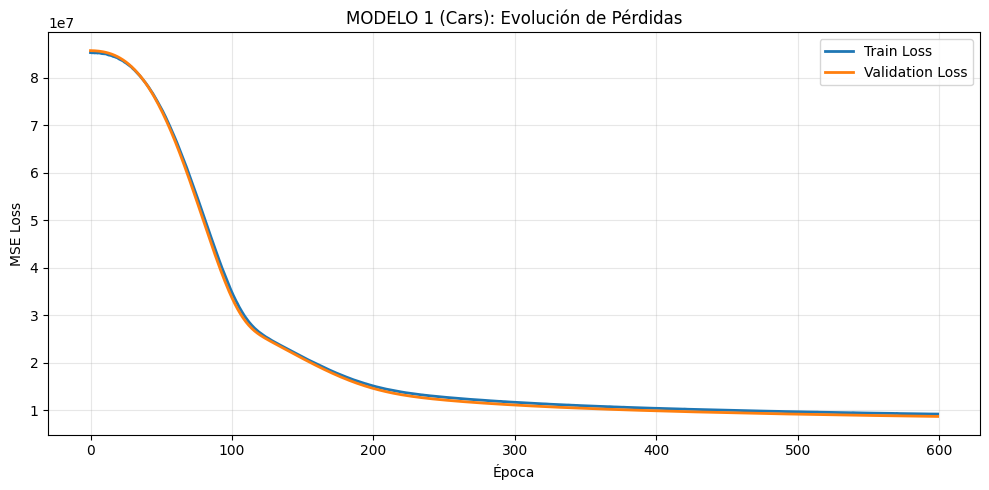


Pérdida final:
  Train: 9180574.6566
  Val:   8680903.8037


In [ ]:
# Graficar pérdidos de entrenamiento
plt.figure(figsize=(10, 5))
plt.plot(losses_cars, label='Train Loss', linewidth=2)
plt.plot(val_losses_cars, label='Validation Loss', linewidth=2)
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.title('MODELO 1 (Cars): Evolución de Pérdidas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPérdida final:")
print(f"  Train: {losses_cars[-1]:.4f}")
print(f"  Val:   {val_losses_cars[-1]:.4f}")

### 1.9 EVALUACIÓN EN TEST SET


EVALUACIÓN - MODELO 1 (CARS)
 ▶ R2 Score: 0.7850
 ▶ MAE:      $1830.20
 ▶ RMSE:     $2949.84

Ejemplos de predicciones (primeros 10):
 Real: $14,500 | Predicción: $15,425
 Real: $11,950 | Predicción: $9,894
 Real: $1,150 | Predicción: $3,348
 Real: $8,300 | Predicción: $13,199
 Real: $7,600 | Predicción: $6,091
 Real: $6,500 | Predicción: $10,068
 Real: $2,200 | Predicción: $2,101
 Real: $800 | Predicción: $1,242
 Real: $518 | Predicción: $1,023
 Real: $10,600 | Predicción: $7,736


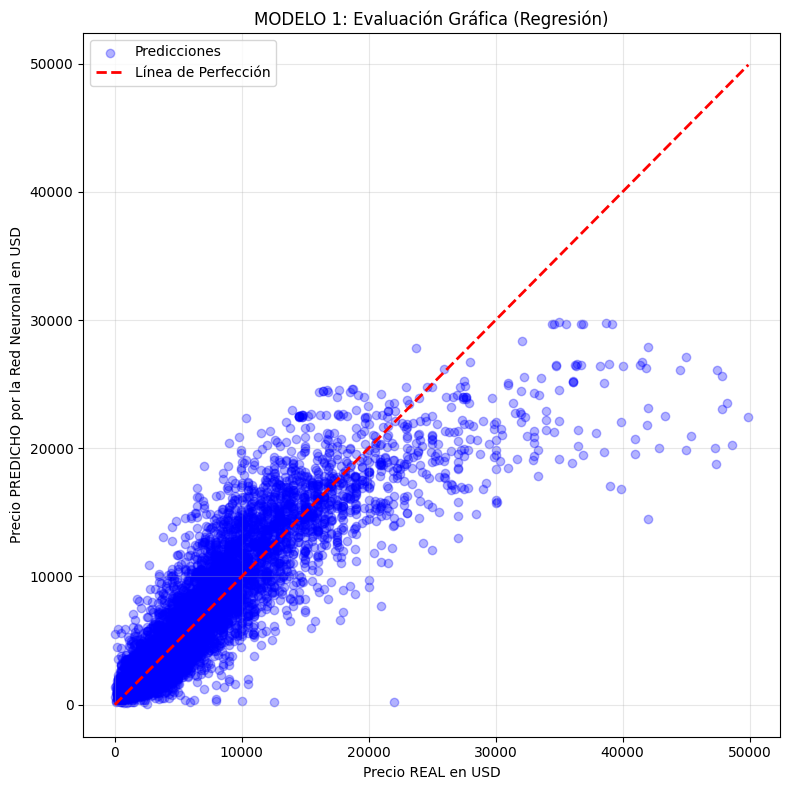

In [ ]:
# ==========================================
# 1.9 EVALUACIÓN EN TEST SET
# ==========================================

# 1. Realizar predicciones en el test set
model_cars.eval()
with torch.no_grad():
    y_pred_cars = model_cars(X_test_cars_t).cpu().numpy()

# 2. Calcular Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

r2_cars = r2_score(y_test_cars, y_pred_cars)
mae_cars = mean_absolute_error(y_test_cars, y_pred_cars)
rmse_cars = np.sqrt(mean_squared_error(y_test_cars, y_pred_cars))

print(f"\n{'='*50}")
print(f"EVALUACIÓN - MODELO 1 (CARS)")
print(f"{'='*50}")
print(f" ▶ R2 Score: {r2_cars:.4f}")
print(f" ▶ MAE:      ${mae_cars:.2f}")
print(f" ▶ RMSE:     ${rmse_cars:.2f}")

# 3. Mostrar Ejemplos de predicciones (primeros 10)
print(f"\nEjemplos de predicciones (primeros 10):")
for i in range(min(10, len(y_test_cars))):
    print(f" Real: ${y_test_cars[i]:,.0f} | Predicción: ${y_pred_cars[i,0]:,.0f}")

# 4. Gráfica de Predicciones vs Valores Reales (Modelo 1)
plt.figure(figsize=(8, 8))
# Graficamos los valores reales vs predichos
plt.scatter(y_test_cars, y_pred_cars.flatten(), alpha=0.3, color='blue', label='Predicciones')

# Línea ideal (donde la predicción es exactamente igual al valor real)
max_val = max(y_test_cars.max(), y_pred_cars.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Línea de Perfección')

plt.xlabel('Precio REAL en USD')
plt.ylabel('Precio PREDICHO por la Red Neuronal en USD')
plt.title('MODELO 1: Evaluación Gráfica (Regresión)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.10 GUARDAR CHECKPOINT (Del cuadernillo PyTorch 04)

In [ ]:
# Guardar estado del modelo
checkpoint_cars = {
    'model_state_dict': model_cars.state_dict(),
    'optimizer_state_dict': optimizer_cars.state_dict(),
    'epoch': num_epochs_cars,
    'r2_score': r2_cars,
    'mae': mae_cars,
    'normalization_params': {'mu': mu_cars, 'sigma': sigma_cars}
}

torch.save(checkpoint_cars, 'model_cars_checkpoint.pth')
print(f"\n✓ Checkpoint guardado: 'model_cars_checkpoint.pth'")
print(f"  Contiene: modelo, optimizador, métricas y parámetros de normalización")


✓ Checkpoint guardado: 'model_cars_checkpoint.pth'
  Contiene: modelo, optimizador, métricas y parámetros de normalización


### Componentes del Checkpoint Guardado

1.  **`state_dict()`**: Devuelve un diccionario que contiene todos los parámetros aprendidos del modelo, como los pesos y sesgos de las capas.
2.  Se guardan elementos adicionales cruciales:
    -   El estado del optimizador (para reanudar el entrenamiento si fuera necesario).
    -   La época actual del entrenamiento.
    -   Métricas de evaluación relevantes.
    -   Los **parámetros de normalización** (media y desviación estándar), que son **esenciales** para aplicar la misma transformación a nuevos datos durante la inferencia.
3.  `.pth`: Es la extensión de archivo convencional para guardar modelos PyTorch.

### 1.11 CARGA Y USO DEL MODELO GUARDADO

In [ ]:
# Crear nuevo modelo y cargar checkpoint
model_cars_loaded = RegressionNN_Cars(input_size=n_cars).to(device)
checkpoint_loaded = torch.load('model_cars_checkpoint.pth', weights_only=False)
model_cars_loaded.load_state_dict(checkpoint_loaded['model_state_dict'])

print(f"\n✓ Modelo cargado desde checkpoint")
print(f"  R² Score (guardado): {checkpoint_loaded['r2_score']:.4f}")
print(f"  MAE (guardado): ${checkpoint_loaded['mae']:.2f}")


✓ Modelo cargado desde checkpoint
  R² Score (guardado): 0.7850
  MAE (guardado): $1830.20


### 1.12 PREDICCIONES EN NUEVOS DATOS

In [ ]:
# Hacer predicciones en nuevos datos usando el modelo cargado
model_cars_loaded.eval()

# Seleccionar 5 ejemplos al azar del test set
indices_sample = np.random.choice(len(X_test_cars_norm), size=5, replace=False)
X_sample = X_test_cars_norm[indices_sample]
y_sample = y_test_cars[indices_sample]

print(f"\n{'='*50}")
print(f"PREDICCIONES NUEVAS - MODELO 1 (CARS)")
print(f"{'='*50}")

with torch.no_grad():
    X_sample_t = torch.from_numpy(X_sample).float().to(device)
    y_pred_sample = model_cars_loaded(X_sample_t).cpu().numpy()

    for i in range(len(X_sample)):
        print(f"\nEjemplo {i+1}:")
        print(f"  Precio REAL:      ${y_sample[i]:,.0f}")
        print(f"  Precio PREDICHO:  ${y_pred_sample[i, 0]:,.0f}")
        error_pct = abs(y_sample[i] - y_pred_sample[i, 0]) / y_sample[i] * 100
        print(f"  Error relativo:   {error_pct:.2f}%")


PREDICCIONES NUEVAS - MODELO 1 (CARS)

Ejemplo 1:
  Precio REAL:      $32,100
  Precio PREDICHO:  $28,341
  Error relativo:   11.71%

Ejemplo 2:
  Precio REAL:      $5,100
  Precio PREDICHO:  $5,121
  Error relativo:   0.42%

Ejemplo 3:
  Precio REAL:      $12,000
  Precio PREDICHO:  $7,690
  Error relativo:   35.92%

Ejemplo 4:
  Precio REAL:      $9,600
  Precio PREDICHO:  $7,531
  Error relativo:   21.55%

Ejemplo 5:
  Precio REAL:      $5,200
  Precio PREDICHO:  $4,417
  Error relativo:   15.07%


## 📦 BLOQUE 2: MODELO 2 - CLASIFICACIÓN BINARIA (DDoS Detection)

### 2.1 PROPÓSITO Y CONTEXTO

**Dataset**: `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv`
**Tarea**: **Clasificación Binaria** → Detección automatizada de ataques de Denegación de Servicio (DDoS) frente a tráfico legítimo (BENIGN).

**Análisis del Dataset**:
* **Volumen masivo**: 225,711 registros de tráfico de red.
* **Dimensiones**: 78 características técnicas (estadísticas de flujo, longitud de paquetes, duraciones, etc.).
* **Desafío de Desbalanceo**: Originalmente, las clases BENIGN y DDoS no están distribuidas equitativamente, lo que requiere una estrategia de muestreo para evitar sesgos en la red neuronal.

**Metodología de Implementación**:
1. **Limpieza Rigurosa**: Eliminación de valores infinitos y nulos tras la conversión de tipos.
2. **Balanceo de Clases**: Aplicación de **Undersampling** para igualar ambas categorías a 97,686 muestras cada una, garantizando un entrenamiento equitativo.
3. **Optimización**: Normalización Z-score con protección de *Data Leakage*.
4. **Arquitectura**: DNN de 4 capas densas con activación **Sigmoid** en la salida para la interpretación de probabilidades.
5. **Métricas de Evaluación**: Dado que es clasificación, se prioriza el Accuracy, Precision, Recall y F1-Score.

### 2.2 CARGA Y PREPROCESAMIENTO

In [ ]:
# ==========================================
# 2.2 CARGA, IMPUTACIÓN Y BALANCEO DE DATOS
# ==========================================


# Cargar dataset DDoS
print("Cargando Friday-WorkingHours (este proceso puede tomar un momento)...")
ruta_ddos = '/content/drive/MyDrive/IA2026/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
df_ddos = pd.read_csv(ruta_ddos, low_memory=False)

# Limpieza de nombres de columnas
df_ddos.columns = df_ddos.columns.str.strip()

print(f"\n{'='*80}")
print("ESTADO ANTES DE LA IMPUTACIÓN")
print(f"{'='*80}")
# Transformación de valores infinitos a nulos (NaN) para permitir su imputación
df_ddos.replace([np.inf, -np.inf], np.nan, inplace=True)
nulos_antes = df_ddos.isnull().sum().sum()
print(f"Total de celdas vacías o infinitas (NaN): {nulos_antes}")
print(f"Filas totales originales: {df_ddos.shape[0]}\n")

# --- MUESTRA DEL DATASET ORIGINAL ---
print("MUESTRA DEL DATASET ORIGINAL (Primeras 20 filas)")
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    display(df_ddos.head(20))
print("\n")

# --- PROCESO DE IMPUTACIÓN ---
print("Iniciando imputación de datos...")
columnas_num_ddos = df_ddos.select_dtypes(include=['float64', 'int64']).columns
columnas_cat_ddos = df_ddos.select_dtypes(include=['object', 'bool']).columns

# 1. Numéricas -> Imputación mediante la Mediana
for col in columnas_num_ddos:
    df_ddos[col] = df_ddos[col].fillna(df_ddos[col].median())

# 2. Categóricas -> Imputación mediante la Moda
for col in columnas_cat_ddos:
    df_ddos[col] = df_ddos[col].fillna(df_ddos[col].mode()[0])

# Mapear etiquetas de texto a valores numéricos binarios
df_ddos['Label'] = df_ddos['Label'].map({'BENIGN': 0, 'DDoS': 1})

print(f"{'='*80}")
print("ESTADO DESPUÉS DE LA IMPUTACIÓN Y CODIFICACIÓN")
print(f"{'='*80}")
nulos_despues = df_ddos.isnull().sum().sum()
print(f"Total de celdas vacías (NaN): {nulos_despues}")
print(f"Filas totales conservadas: {df_ddos.shape[0]}\n")

# --- MUESTRA DEL DATASET TRANSFORMADO ---
print("MUESTRA DEL DATASET IMPUTADO Y CODIFICADO (Primeras 20 filas)")
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    display(df_ddos.head(20))
print("\n")

# =======================================================================
# MATRIZ DE CARACTERÍSTICAS (Features)
# =======================================================================
todas_las_columnas = df_ddos.columns.tolist()
columnas_entrada = [col for col in todas_las_columnas if col != 'Label']

print(f"{'='*90}")
print(f"MATRIZ DE CARACTERÍSTICAS UTILIZADAS ({len(columnas_entrada)} variables de red)")
print(f"{'='*90}")
for i in range(0, len(columnas_entrada), 3):
    fila = columnas_entrada[i:i+3]
    print(" | ".join([f"{col:<28}" for col in fila]))
print(f"{'='*90}\n")

# =======================================================================
# BALANCEO DE CLASES (Undersampling)
# =======================================================================
conteo_antes_bal = df_ddos['Label'].value_counts()
clase_0 = df_ddos[df_ddos['Label'] == 0]
clase_1 = df_ddos[df_ddos['Label'] == 1]
min_size = min(len(clase_0), len(clase_1))

clase_0_bal = clase_0.sample(n=min_size, random_state=42)
clase_1_bal = clase_1.sample(n=min_size, random_state=42)

df_ddos = pd.concat([clase_0_bal, clase_1_bal]).sample(frac=1, random_state=42).reset_index(drop=True)
conteo_despues_bal = df_ddos['Label'].value_counts()

tabla_balance = pd.DataFrame({
    'Clase de Tráfico': ['DDoS (Ataque - 1)', 'BENIGN (Normal - 0)'],
    'Antes del Balanceo': [conteo_antes_bal.get(1, 0), conteo_antes_bal.get(0, 0)],
    'Después del Balanceo': [conteo_despues_bal.get(1, 0), conteo_despues_bal.get(0, 0)]
}).set_index('Clase de Tráfico')

print(f"{'='*60}")
print("MATRIZ DE BALANCEO DE DATOS (UNDERSAMPLING)")
print(f"{'='*60}")
print(tabla_balance.to_string())
print(f"{'='*60}\n")

# =======================================================================
# EXTRACCIÓN DE CARACTERÍSTICAS (Post-Balanceo)
# =======================================================================
X_ddos = df_ddos.drop('Label', axis=1).values
y_ddos = df_ddos['Label'].values
m_ddos, n_ddos = X_ddos.shape

print(f"Dataset final preparado para entrenamiento:")
print(f" - Ejemplos totales (m): {m_ddos}")
print(f" - Características (n): {n_ddos}")

Cargando Friday-WorkingHours (este proceso puede tomar un momento)...

ESTADO ANTES DE LA IMPUTACIÓN
Total de celdas vacías o infinitas (NaN): 68
Filas totales originales: 225745

MUESTRA DEL DATASET ORIGINAL (Primeras 20 filas)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.0,4.000000e+06,6.666667e+05,3.0,0.000000,3,3,3,3.0,0.000000,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.000000,0.000000,6,6,6.0,0.0,1.100917e+05,1.834862e+04,109.0,0.000000,109,109,0,0.0,0.000000,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9.174312e+03,9174.311927,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000000,6.000000,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.000000,0.000000,6,6,6.0,0.0,2.307692e+05,3.846154e+04,52.0,0.000000,52,52,0,0.0,0.000000,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,1.923077e+04,19230.769230,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000000,6.000000,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.000000,0.000000,6,6,6.0,0.0,3.529412e+05,5.882353e+04,34.0,0.000000,34,34,0,0.0,0.000000,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,2.941176e+04,29411.764710,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000000,6.000000,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.0,4.000000e+06,6.666667e+05,3.0,0.000000,3,3,3,3.0,0.000000,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
5,54871,1022,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.0,1.174168e+04,1.956947e+03,1022.0,0.000000,1022,1022,1022,1022.0,0.000000,1022,1022,0,0.0,0.0,0,0,0,0,0,0,40,0,1.956947e+03,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
6,54925,4,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.0,3.000000e+06,5.000000e+05,4.0,0.000000,4,4,4,4.0,0.000000,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
7,54925,42,1,1,6,6,6,6,6.000000,0.000000,6,6,6.0,0.0,2.857143e+05,4.761905e+04,42.0,0.000000,42,42,0,0.0,0.000000,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,2.380952e+04,23809.523810,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,1,9.000000,6.000000,6.0,20,0,0,0,0,0,0,1,6,1,6,32,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
8,9282,4,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.0,3.000000e+06,5.000000e+05,4.0,0.000000,4,4,4,4.0,0.000000,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,9.000000,6



Iniciando imputación de datos...
ESTADO DESPUÉS DE LA IMPUTACIÓN Y CODIFICACIÓN
Total de celdas vacías (NaN): 0
Filas totales conservadas: 225745

MUESTRA DEL DATASET IMPUTADO Y CODIFICADO (Primeras 20 filas)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.0,4.000000e+06,6.666667e+05,3.0,0.000000,3,3,3,3.0,0.000000,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.000000,0.000000,6,6,6.0,0.0,1.100917e+05,1.834862e+04,109.0,0.000000,109,109,0,0.0,0.000000,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9.174312e+03,9174.311927,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000000,6.000000,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.000000,0.000000,6,6,6.0,0.0,2.307692e+05,3.846154e+04,52.0,0.000000,52,52,0,0.0,0.000000,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,1.923077e+04,19230.769230,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000000,6.000000,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.000000,0.000000,6,6,6.0,0.0,3.529412e+05,5.882353e+04,34.0,0.000000,34,34,0,0.0,0.000000,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,2.941176e+04,29411.764710,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,1,9.000000,6.000000,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.0,4.000000e+06,6.666667e+05,3.0,0.000000,3,3,3,3.0,0.000000,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
5,54871,1022,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.0,1.174168e+04,1.956947e+03,1022.0,0.000000,1022,1022,1022,1022.0,0.000000,1022,1022,0,0.0,0.0,0,0,0,0,0,0,40,0,1.956947e+03,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
6,54925,4,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.0,3.000000e+06,5.000000e+05,4.0,0.000000,4,4,4,4.0,0.000000,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,0
7,54925,42,1,1,6,6,6,6,6.000000,0.000000,6,6,6.0,0.0,2.857143e+05,4.761905e+04,42.0,0.000000,42,42,0,0.0,0.000000,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,2.380952e+04,23809.523810,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,1,9.000000,6.000000,6.0,20,0,0,0,0,0,0,1,6,1,6,32,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,0
8,9282,4,2,0,12,0,6,6,6.000000,0.000000,0,0,0.0,0.0,3.000000e+06,5.000000e+05,4.0,0.000000,4,4,4,4.0,0.000000,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,9.000000,6.000000,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-



MATRIZ DE CARACTERÍSTICAS UTILIZADAS (78 variables de red)
Destination Port             | Flow Duration                | Total Fwd Packets           
Total Backward Packets       | Total Length of Fwd Packets  | Total Length of Bwd Packets 
Fwd Packet Length Max        | Fwd Packet Length Min        | Fwd Packet Length Mean      
Fwd Packet Length Std        | Bwd Packet Length Max        | Bwd Packet Length Min       
Bwd Packet Length Mean       | Bwd Packet Length Std        | Flow Bytes/s                
Flow Packets/s               | Flow IAT Mean                | Flow IAT Std                
Flow IAT Max                 | Flow IAT Min                 | Fwd IAT Total               
Fwd IAT Mean                 | Fwd IAT Std                  | Fwd IAT Max                 
Fwd IAT Min                  | Bwd IAT Total                | Bwd IAT Mean                
Bwd IAT Std                  | Bwd IAT Max                  | Bwd IAT Min                 
Fwd PSH Flags                

In [ ]:
# ==========================================
# 2.2.1 SPLIT, NORMALIZACIÓN Y DATALOADERS
# ==========================================

# 1. Split 80/20
np.random.seed(42)
indices = np.random.permutation(m_ddos)
split_idx = int(0.8 * m_ddos)

X_train_ddos = X_ddos[indices[:split_idx]].astype(float)
y_train_ddos = y_ddos[indices[:split_idx]].astype(float)
X_test_ddos = X_ddos[indices[split_idx:]].astype(float)
y_test_ddos = y_ddos[indices[split_idx:]].astype(float)

# 2. Normalización Z-score (SOLO con estadísticas de TRAIN)
mu_ddos = np.mean(X_train_ddos, axis=0)
sigma_ddos = np.std(X_train_ddos, axis=0)
sigma_ddos[sigma_ddos == 0] = 1

X_train_ddos_norm = (X_train_ddos - mu_ddos) / sigma_ddos
X_test_ddos_norm = (X_test_ddos - mu_ddos) / sigma_ddos

print(f"\n✓ Split 80/20 y normalización completados")

# 3. Convertir a tensores PyTorch y mover a GPU
X_train_ddos_t = torch.from_numpy(X_train_ddos_norm).float().to(device)
y_train_ddos_t = torch.from_numpy(y_train_ddos).float().unsqueeze(1).to(device)

X_test_ddos_t = torch.from_numpy(X_test_ddos_norm).float().to(device)
y_test_ddos_t = torch.from_numpy(y_test_ddos).float().unsqueeze(1).to(device)

# 4. Creación de DataLoaders
batch_size_ddos = 128
train_dataset_ddos = TensorDataset(X_train_ddos_t, y_train_ddos_t)
test_dataset_ddos = TensorDataset(X_test_ddos_t, y_test_ddos_t)

train_loader_ddos = DataLoader(train_dataset_ddos, batch_size=batch_size_ddos, shuffle=True)
test_loader_ddos = DataLoader(test_dataset_ddos, batch_size=batch_size_ddos, shuffle=False)

print(f"✓ Tensores y DataLoaders creados")


✓ Split 80/20 y normalización completados
✓ Tensores y DataLoaders creados


### 2.3 MODELO NEURONAL BINARIO

**Arquitectura**:
```
Input (78 características)
    ↓
Capa 1: Linear(78 → 256) + ReLU
    ↓
Capa 2: Linear(256 → 128) + ReLU
    ↓
Capa 3: Linear(128 → 64) + ReLU
    ↓
Capa 4: Linear(64 → 1) + Sigmoid [Probabilidad 0-1]
```

**¿Por qué Sigmoid?**
- Comprimen la salida a [0, 1] (interpretable como probabilidad)
- P(DDoS) ≥ 0.5 → predicción: DDoS
- P(DDoS) < 0.5 → predicción: BENIGN

In [ ]:
class BinaryClassifierNN_DDoS(nn.Module):
    """Red Neuronal para Detección de Ataques DDoS"""
    def __init__(self, input_size=78):
        super(BinaryClassifierNN_DDoS, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.sigmoid(self.fc4(x))  # Probabilidad
        return x

model_ddos = BinaryClassifierNN_DDoS(input_size=n_ddos).to(device)
criterion_ddos = nn.BCELoss()  # Binary Cross Entropy
optimizer_ddos = optim.Adam(model_ddos.parameters(), lr=0.001)

print(f"\n✓ Modelo DDoS creado")
print(f"✓ Pérdida: BCELoss")
print(f"✓ Optimizador: Adam")


✓ Modelo DDoS creado
✓ Pérdida: BCELoss
✓ Optimizador: Adam


### 2.4 ENTRENAMIENTO

In [ ]:
# Bloque 2.4
num_epochs_ddos = 60
losses_ddos = []
val_losses_ddos = []
# NUEVAS LISTAS PARA ACCURACY
train_accs_ddos = []
val_accs_ddos = []

best_val_loss_ddos = float('inf')
best_epoch_ddos = 0

print(f"\nEntrenamiento del Modelo DDoS por {num_epochs_ddos} épocas...\n")

for epoch in range(num_epochs_ddos):
    # ENTRENAMIENTO
    model_ddos.train()
    train_loss, correct_train, total_train = 0.0, 0, 0

    for X_batch, y_batch in train_loader_ddos:
        y_pred = model_ddos(X_batch)
        loss = criterion_ddos(y_pred, y_batch)

        optimizer_ddos.zero_grad()
        loss.backward()
        optimizer_ddos.step()

        train_loss += loss.item()

        # Calcular aciertos en entrenamiento
        preds = (y_pred >= 0.5).float()
        correct_train += (preds == y_batch).sum().item()
        total_train += y_batch.size(0)

    train_loss /= len(train_loader_ddos)
    train_acc = correct_train / total_train

    # VALIDACIÓN
    model_ddos.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader_ddos:
            y_pred = model_ddos(X_batch)
            loss = criterion_ddos(y_pred, y_batch)
            val_loss += loss.item()

            # Calcular aciertos en validación
            preds = (y_pred >= 0.5).float()
            correct_val += (preds == y_batch).sum().item()
            total_val += y_batch.size(0)

    val_loss /= len(test_loader_ddos)
    val_acc = correct_val / total_val

    losses_ddos.append(train_loss)
    val_losses_ddos.append(val_loss)
    train_accs_ddos.append(train_acc)
    val_accs_ddos.append(val_acc)

    # Best Model Checkpoint
    if val_loss < best_val_loss_ddos:
        best_val_loss_ddos = val_loss
        best_epoch_ddos = epoch + 1
        checkpoint_ddos_best = {
            'model_state_dict': model_ddos.state_dict(),
            'optimizer_state_dict': optimizer_ddos.state_dict(),
            'epoch': best_epoch_ddos,
            'val_loss': best_val_loss_ddos,
            'normalization_params': {'mu': mu_ddos, 'sigma': sigma_ddos}
        }
        torch.save(checkpoint_ddos_best, 'model_ddos_best.pth')

    if (epoch + 1) % 15 == 0:
        print(f"Época {epoch+1}/{num_epochs_ddos} | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc*100:.2f}%")

print(f"\n✓ Entrenamiento completado")
print(f"Cargando el mejor modelo de la época {best_epoch_ddos}...")
mejor_checkpoint_ddos = torch.load('model_ddos_best.pth', weights_only=False)
model_ddos.load_state_dict(mejor_checkpoint_ddos['model_state_dict'])
print("✓ El modelo de DDoS en memoria ahora es la mejor versión.")




Entrenamiento del Modelo DDoS por 60 épocas...

Época 15/60 | Val Loss: 0.0017 | Val Accuracy: 99.94%
Época 30/60 | Val Loss: 0.0013 | Val Accuracy: 99.96%
Época 45/60 | Val Loss: 0.0012 | Val Accuracy: 99.96%
Época 60/60 | Val Loss: 0.0036 | Val Accuracy: 99.97%

✓ Entrenamiento completado
Cargando el mejor modelo de la época 34...
✓ El modelo de DDoS en memoria ahora es la mejor versión.


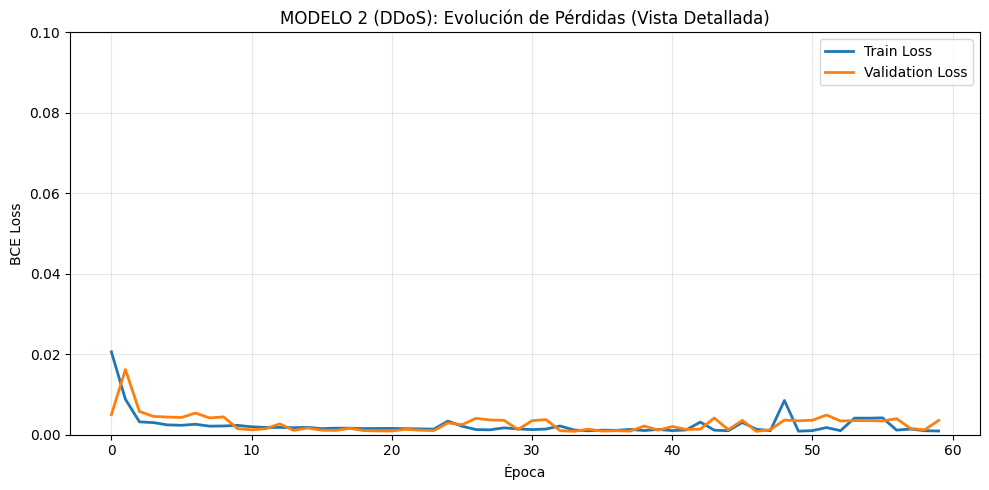

In [ ]:

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(losses_ddos, label='Train Loss', linewidth=2)
plt.plot(val_losses_ddos, label='Validation Loss', linewidth=2)

# =======================================================================
# EL TRUCO DEL ZOOM (Ajuste de límites)
# Subimos el techo a 0.10 para que la línea respire y no se pegue al borde superior
plt.ylim(0.0, 0.10)
# =======================================================================

plt.xlabel('Época')
plt.ylabel('BCE Loss')
plt.title('MODELO 2 (DDoS): Evolución de Pérdidas (Vista Detallada)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

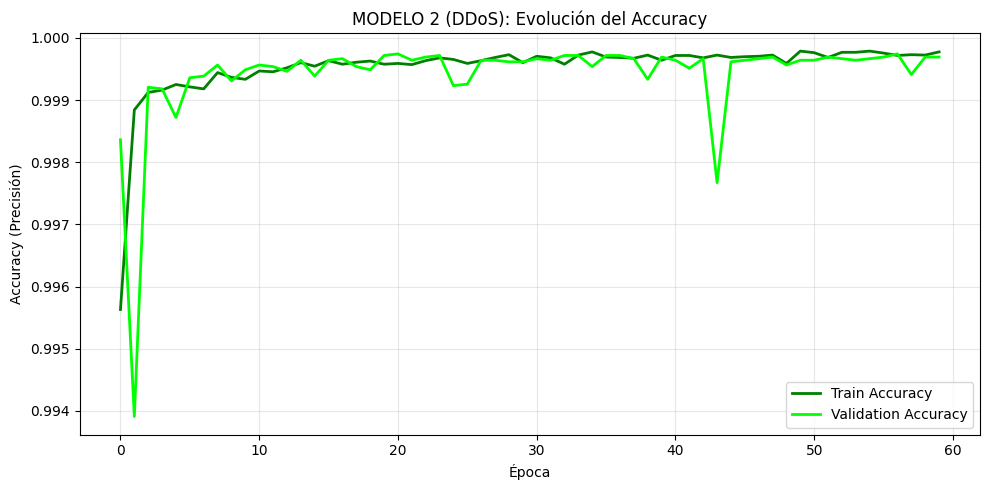

In [ ]:
# ==========================================
# GRAFICAR ACCURACY DDOS
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(train_accs_ddos, label='Train Accuracy', linewidth=2, color='green')
plt.plot(val_accs_ddos, label='Validation Accuracy', linewidth=2, color='lime')
plt.xlabel('Época')
plt.ylabel('Accuracy (Precisión)')
plt.title('MODELO 2 (DDoS): Evolución del Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2.5 EVALUACIÓN Y MÉTRICAS

In [ ]:
# Predicciones
model_ddos.eval()
with torch.no_grad():
    y_pred_prob_ddos = model_ddos(X_test_ddos_t).cpu().numpy()

y_pred_ddos = (y_pred_prob_ddos >= 0.5).astype(int).flatten()

# Métricas
accuracy_ddos = accuracy_score(y_test_ddos, y_pred_ddos)
precision_ddos = precision_score(y_test_ddos, y_pred_ddos)
recall_ddos = recall_score(y_test_ddos, y_pred_ddos)
f1_ddos = f1_score(y_test_ddos, y_pred_ddos)

print(f"\n{'='*50}")
print(f"EVALUACIÓN - MODELO 2 (DDoS)")
print(f"{'='*50}")
print(f"Accuracy:  {accuracy_ddos:.4f}")
print(f"Precision: {precision_ddos:.4f}")
print(f"Recall:    {recall_ddos:.4f}")
print(f"F1-Score:  {f1_ddos:.4f}")


EVALUACIÓN - MODELO 2 (DDoS)
Accuracy:  0.9997
Precision: 0.9998
Recall:    0.9996
F1-Score:  0.9997


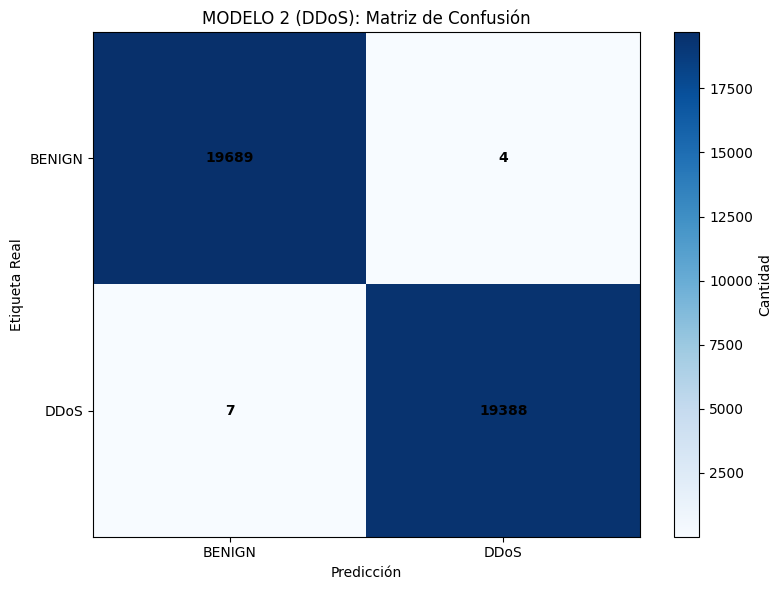

In [ ]:
# Matriz de confusión
cm_ddos = confusion_matrix(y_test_ddos, y_pred_ddos)
plt.figure(figsize=(8, 6))
plt.imshow(cm_ddos, cmap='Blues', aspect='auto')
plt.colorbar(label='Cantidad')

# Anotaciones manuales en la matriz (USANDO SOLO MATPLOTLIB)
for i in range(len(cm_ddos)):
    for j in range(len(cm_ddos)):
        plt.text(j, i, str(cm_ddos[i, j]), ha='center', va='center', color='black', fontweight='bold')

plt.xticks([0, 1], ['BENIGN', 'DDoS'])
plt.yticks([0, 1], ['BENIGN', 'DDoS'])
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción')
plt.title('MODELO 2 (DDoS): Matriz de Confusión')
plt.tight_layout()
plt.show()

In [ ]:
# Guardar checkpoint
checkpoint_ddos = {
    'model_state_dict': model_ddos.state_dict(),
    'optimizer_state_dict': optimizer_ddos.state_dict(),
    'accuracy': accuracy_ddos,
    'f1_score': f1_ddos,
    'normalization_params': {'mu': mu_ddos, 'sigma': sigma_ddos}
}

torch.save(checkpoint_ddos, 'model_ddos_checkpoint.pth')
print(f"\n✓ Checkpoint guardado: 'model_ddos_checkpoint.pth'")


✓ Checkpoint guardado: 'model_ddos_checkpoint.pth'


## 📦 BLOQUE 3: MODELO 3 - CLASIFICACIÓN MULTICLASE (Sensorless Drive)

### 3.1 PROPÓSITO Y CONTEXTO

**Dataset**: `Sensorless_drive_diagnosis_limpio.csv`
**Tarea**: **Clasificación Multiclase** → Identificación automática de 11 estados operativos distintos en motores eléctricos, basándose en la extracción de características de sus señales de corriente y voltaje.

**Análisis del Dataset**:
* **Volumen**: 58,509 registros de lecturas de sensores.
* **Dimensiones**: 48 características continuas anónimas (Feature 0 al 47).
* **Variable Objetivo**: Columna 48 (Clases de fallo del 1 al 11).

**Metodología de Implementación**:
1. **Tratamiento de Etiquetas**: Mapeo estricto del vector objetivo de $[1, 11]$ hacia $[0, 10]$ para cumplir con el requisito de indexación base-cero de la función de pérdida en PyTorch.
2. **Imputación y Verificación**: Manejo de nulos mediante la mediana y volcado de datos para auditoría.
3. **Arquitectura**: DNN diseñada para multiclase con 11 neuronas de salida.
4. **Optimización**: Función de pérdida `CrossEntropyLoss` (que internamente aplica *Softmax*) para evaluar distribuciones de probabilidad sobre las 11 clases.
5. **Evaluación**: Análisis de rendimiento global mediante Accuracy.

---

### 3.2 CARGA, IMPUTACIÓN Y PREPROCESAMIENTO DE DATOS

In [ ]:
# ==========================================
# 3.2 CARGA, IMPUTACIÓN Y PREPROCESAMIENTO
# ==========================================

import numpy as np
import pandas as pd

print("Cargando dataset Sensorless Drive Diagnosis...")
ruta_sensorless = '/content/drive/MyDrive/IA2026/Sensorless_drive_diagnosis_limpio.csv'
# Este dataset no tiene encabezados, Pandas asignará números secuenciales (0 al 48)
df_sensorless = pd.read_csv(ruta_sensorless, header=None)

# Renombramos la última columna a 'Target' para identificar la clase a predecir
df_sensorless.rename(columns={df_sensorless.columns[-1]: 'Target'}, inplace=True)

print(f"\n{'='*80}")
print("ESTADO ANTES DE LA IMPUTACIÓN Y AJUSTE DE CLASES")
print(f"{'='*80}")
nulos_antes_sens = df_sensorless.isnull().sum().sum()
print(f"Total de celdas vacías (NaN): {nulos_antes_sens}")
print(f"Filas totales originales: {df_sensorless.shape[0]}\n")

# --- MUESTRA DEL DATASET ORIGINAL ---
print("MUESTRA DEL DATASET ORIGINAL (Primeras 20 filas)")
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    display(df_sensorless.head(20))
print("\n")

# --- PROCESO DE IMPUTACIÓN ---
print("Iniciando imputación de datos eléctricos...")
columnas_num_sens = df_sensorless.columns.drop('Target')

# 1. Variables continuas (Sensores) -> Imputación mediante la Mediana
for col in columnas_num_sens:
    df_sensorless[col] = df_sensorless[col].fillna(df_sensorless[col].median())

# 2. Ajuste del Target -> PyTorch exige que las clases vayan de 0 a N-1 (0 a 10)
df_sensorless['Target'] = df_sensorless['Target'].fillna(df_sensorless['Target'].mode()[0])
df_sensorless['Target'] = df_sensorless['Target'].astype(int) - 1

print(f"{'='*80}")
print("ESTADO DESPUÉS DE LA IMPUTACIÓN Y REINDEXACIÓN (0-10)")
print(f"{'='*80}")
nulos_despues_sens = df_sensorless.isnull().sum().sum()
print(f"Total de celdas vacías (NaN): {nulos_despues_sens}")
print(f"Filas totales conservadas: {df_sensorless.shape[0]}\n")

# --- MUESTRA DEL DATASET TRANSFORMADO ---
print("MUESTRA DEL DATASET IMPUTADO Y REINDEXADO (Primeras 20 filas)")
with pd.option_context('display.max_columns', None, 'display.width', 1000):
    display(df_sensorless.head(20))
print("\n")

# =======================================================================
# MATRIZ DE CARACTERÍSTICAS (Features)
# =======================================================================
columnas_entrada_sensor = [col for col in df_sensorless.columns if col != 'Target']

print(f"{'='*90}")
print(f"MATRIZ DE CARACTERÍSTICAS UTILIZADAS ({len(columnas_entrada_sensor)} variables eléctricas)")
print(f"{'='*90}")

# Imprimir en formato de matriz elegante (4 columnas alineadas)
for i in range(0, len(columnas_entrada_sensor), 4):
    fila = columnas_entrada_sensor[i:i+4]
    print(" | ".join([f"Feature {str(col):<12}" for col in fila]))
print(f"{'='*90}\n")

# =======================================================================
# EXTRACCIÓN DE TENSORES
# =======================================================================
# Separar características (X) y objetivo (y)
X_sensor = df_sensorless.drop('Target', axis=1).values.astype(float)
y_sensor = df_sensorless['Target'].values.astype(int)
m_sensor, n_sensor = X_sensor.shape

print(f"Dataset final preparado para entrenamiento:")
print(f" - Ejemplos totales (m): {m_sensor}")
print(f" - Características de entrada (n): {n_sensor}")
print(f" - Espacio de clases objetivo: {len(np.unique(y_sensor))} (Indexadas de 0 a 10)")

Cargando dataset Sensorless Drive Diagnosis...

ESTADO ANTES DE LA IMPUTACIÓN Y AJUSTE DE CLASES
Total de celdas vacías (NaN): 0
Filas totales originales: 58509

MUESTRA DEL DATASET ORIGINAL (Primeras 20 filas)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,Target
0,-3.014600e-07,8.260300e-06,-1.151700e-05,-2.309800e-06,-1.438600e-06,-2.122500e-05,0.031718,0.031710,0.031721,-0.032963,-0.032962,-0.032941,0.000769,0.000232,0.000600,0.000757,0.000247,0.000725,0.89669,0.89669,0.89669,0.89658,0.89658,0.89656,0.007680,0.257360,-0.711840,0.004879,-0.095775,-0.441260,-0.001317,-0.001319,-0.001248,-0.004378,-0.004384,-0.004389,-0.66732,4.3662,6.0168,-0.63308,2.9646,8.1198,-1.4961,-1.4961,-1.4961,-1.4996,-1.4996,-1.4996,1
1,2.913200e-06,-5.247700e-06,3.342100e-06,-6.056100e-06,2.778900e-06,-3.752400e-06,0.030804,0.030810,0.030806,-0.033520,-0.033522,-0.033519,0.000766,0.000221,0.000485,0.000755,0.000252,0.000668,0.89583,0.89583,0.89580,0.89677,0.89677,0.89673,-0.009402,-0.059481,-0.295920,0.007111,0.119110,0.311170,0.001093,0.001091,0.001068,-0.001344,-0.001342,-0.001375,-0.65404,1.3977,3.6048,-0.59314,7.6252,6.1690,-1.4967,-1.4967,-1.4967,-1.5005,-1.5005,-1.5005,1
2,-2.951700e-06,-3.184000e-06,-1.592000e-05,-1.208400e-06,-1.575300e-06,1.739400e-05,0.032877,0.032880,0.032896,-0.029834,-0.029832,-0.029849,0.000764,0.000230,0.000560,0.000758,0.000236,0.000712,0.89583,0.89583,0.89581,0.89619,0.89619,0.89621,0.005951,-0.075239,-0.228620,0.000445,-0.162300,0.562100,0.002894,0.002903,0.002885,0.000350,0.000358,0.000374,-0.67146,2.8072,5.8007,-0.63252,2.7784,5.3017,-1.4983,-1.4983,-1.4982,-1.4985,-1.4985,-1.4985,1
3,-1.322600e-06,8.820100e-06,-1.587900e-05,-4.811100e-06,-7.282900e-07,4.143900e-06,0.029410,0.029401,0.029417,-0.030156,-0.030155,-0.030159,0.000770,0.000244,0.000753,0.000755,0.000257,0.000754,0.89480,0.89481,0.89479,0.89576,0.89576,0.89572,0.002056,0.466570,0.568410,0.006936,-0.467240,0.226730,-0.001255,-0.001242,-0.001277,-0.004974,-0.004966,-0.004976,-0.67766,7.8629,23.3960,-0.62289,6.5534,6.2606,-1.4963,-1.4963,-1.4963,-1.4975,-1.4975,-1.4976,1
4,-6.836600e-08,5.666300e-07,-2.590600e-05,-6.490100e-06,-7.940600e-07,1.349100e-05,0.030119,0.030119,0.030145,-0.031393,-0.031392,-0.031405,0.000763,0.000249,0.000623,0.000756,0.000225,0.000612,0.89656,0.89656,0.89655,0.89521,0.89520,0.89520,-0.000860,-0.904870,-0.573950,0.005616,0.343380,0.843070,-0.003811,-0.003804,-0.003800,-0.004655,-0.004646,-0.004640,-0.65867,14.8720,5.0582,-0.63010,4.5155,9.5231,-1.4958,-1.4958,-1.4958,-1.4959,-1.4959,-1.4959,1
5,-9.584900e-07,5.214300e-08,-4.735900e-05,6.453700e-07,-2.304100e-06,5.499900e-05,0.031154,0.031154,0.031201,-0.032789,-0.032787,-0.032842,0.000767,0.000252,0.000643,0.000758,0.000266,0.000736,0.89458,0.89458,0.89455,0.89573,0.89572,0.89572,0.000483,0.164030,-0.131240,0.001298,-0.048862,2.218500,-0.002898,-0.002898,-0.002868,-0.001519,-0.001519,-0.001410,-0.65298,7.3162,3.9757,-0.61124,5.8337,18.6970,-1.4956,-1.4956,-1.4956,-1.4973,-1.4972,-1.4973,1
6,-1.783700e-06,1.303600e-06,-3.785100e-05,-7.083900e-06,6.706300e-06,2.207400e-05,0.033805,0.033804,0.033841,-0.033345,-0.033352,-0.033374,0.000767,0.000233,0.000582,0.000755,0.000306,0.000707,0.89622,0.89622,0.89621,0.89617,0.89617,0.89613,0.003751,0.235330,-0.263810,0.008790,-0.524480,-0.102930,-0.005763,-0.005766,-0.005784,-0.002934,-0.002942,-0.002986,-0.65485,2.2604,2.7104,-0.62501,17.6180,9.0823,-1.4960,-1.4960,-1.4959,-1.4954,-1.4954,-1.4953,1
7,-2.566600e-06,-1.679500e-07,1.483800e-05,-1.598400e-06,8.709200e-07,1.496100e-05,0.031071,0.031071,0.031056,-0.029695,-0.029696,-0.029711,0.000766,0.000228,0.000654,0.000757,0.000256,0.000676,0.89635,0.89634,0.89634,0.89864,0.89864,0.89862,0.002025,-1.080900,0.407670,0.001461,-0.487020,0.524550,-0.002304,-0.002292,-0.002307,-0.003338,-0.003324,-0.003319,-0.64483,11.9410,9.8584,-0.63618,12.8380,4.9079,-1.4990,-1.4990,-1.4990,-1.4968,-1.4968,-1.4968,1
8,-5.474000e-06,1.086500e-07,-1.097200e-05,-1.815600e-06,4.757800e-07,2.378300e-05,0.031309,0.031308,0.031319,-0.031344,-0.031345,-0.031368,0.000769,0.000229,0.000547,0.000759,0.000244,0.000713,0.89718,0.89718,0.89715,0



Iniciando imputación de datos eléctricos...
ESTADO DESPUÉS DE LA IMPUTACIÓN Y REINDEXACIÓN (0-10)
Total de celdas vacías (NaN): 0
Filas totales conservadas: 58509

MUESTRA DEL DATASET IMPUTADO Y REINDEXADO (Primeras 20 filas)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,Target
0,-3.014600e-07,8.260300e-06,-1.151700e-05,-2.309800e-06,-1.438600e-06,-2.122500e-05,0.031718,0.031710,0.031721,-0.032963,-0.032962,-0.032941,0.000769,0.000232,0.000600,0.000757,0.000247,0.000725,0.89669,0.89669,0.89669,0.89658,0.89658,0.89656,0.007680,0.257360,-0.711840,0.004879,-0.095775,-0.441260,-0.001317,-0.001319,-0.001248,-0.004378,-0.004384,-0.004389,-0.66732,4.3662,6.0168,-0.63308,2.9646,8.1198,-1.4961,-1.4961,-1.4961,-1.4996,-1.4996,-1.4996,0
1,2.913200e-06,-5.247700e-06,3.342100e-06,-6.056100e-06,2.778900e-06,-3.752400e-06,0.030804,0.030810,0.030806,-0.033520,-0.033522,-0.033519,0.000766,0.000221,0.000485,0.000755,0.000252,0.000668,0.89583,0.89583,0.89580,0.89677,0.89677,0.89673,-0.009402,-0.059481,-0.295920,0.007111,0.119110,0.311170,0.001093,0.001091,0.001068,-0.001344,-0.001342,-0.001375,-0.65404,1.3977,3.6048,-0.59314,7.6252,6.1690,-1.4967,-1.4967,-1.4967,-1.5005,-1.5005,-1.5005,0
2,-2.951700e-06,-3.184000e-06,-1.592000e-05,-1.208400e-06,-1.575300e-06,1.739400e-05,0.032877,0.032880,0.032896,-0.029834,-0.029832,-0.029849,0.000764,0.000230,0.000560,0.000758,0.000236,0.000712,0.89583,0.89583,0.89581,0.89619,0.89619,0.89621,0.005951,-0.075239,-0.228620,0.000445,-0.162300,0.562100,0.002894,0.002903,0.002885,0.000350,0.000358,0.000374,-0.67146,2.8072,5.8007,-0.63252,2.7784,5.3017,-1.4983,-1.4983,-1.4982,-1.4985,-1.4985,-1.4985,0
3,-1.322600e-06,8.820100e-06,-1.587900e-05,-4.811100e-06,-7.282900e-07,4.143900e-06,0.029410,0.029401,0.029417,-0.030156,-0.030155,-0.030159,0.000770,0.000244,0.000753,0.000755,0.000257,0.000754,0.89480,0.89481,0.89479,0.89576,0.89576,0.89572,0.002056,0.466570,0.568410,0.006936,-0.467240,0.226730,-0.001255,-0.001242,-0.001277,-0.004974,-0.004966,-0.004976,-0.67766,7.8629,23.3960,-0.62289,6.5534,6.2606,-1.4963,-1.4963,-1.4963,-1.4975,-1.4975,-1.4976,0
4,-6.836600e-08,5.666300e-07,-2.590600e-05,-6.490100e-06,-7.940600e-07,1.349100e-05,0.030119,0.030119,0.030145,-0.031393,-0.031392,-0.031405,0.000763,0.000249,0.000623,0.000756,0.000225,0.000612,0.89656,0.89656,0.89655,0.89521,0.89520,0.89520,-0.000860,-0.904870,-0.573950,0.005616,0.343380,0.843070,-0.003811,-0.003804,-0.003800,-0.004655,-0.004646,-0.004640,-0.65867,14.8720,5.0582,-0.63010,4.5155,9.5231,-1.4958,-1.4958,-1.4958,-1.4959,-1.4959,-1.4959,0
5,-9.584900e-07,5.214300e-08,-4.735900e-05,6.453700e-07,-2.304100e-06,5.499900e-05,0.031154,0.031154,0.031201,-0.032789,-0.032787,-0.032842,0.000767,0.000252,0.000643,0.000758,0.000266,0.000736,0.89458,0.89458,0.89455,0.89573,0.89572,0.89572,0.000483,0.164030,-0.131240,0.001298,-0.048862,2.218500,-0.002898,-0.002898,-0.002868,-0.001519,-0.001519,-0.001410,-0.65298,7.3162,3.9757,-0.61124,5.8337,18.6970,-1.4956,-1.4956,-1.4956,-1.4973,-1.4972,-1.4973,0
6,-1.783700e-06,1.303600e-06,-3.785100e-05,-7.083900e-06,6.706300e-06,2.207400e-05,0.033805,0.033804,0.033841,-0.033345,-0.033352,-0.033374,0.000767,0.000233,0.000582,0.000755,0.000306,0.000707,0.89622,0.89622,0.89621,0.89617,0.89617,0.89613,0.003751,0.235330,-0.263810,0.008790,-0.524480,-0.102930,-0.005763,-0.005766,-0.005784,-0.002934,-0.002942,-0.002986,-0.65485,2.2604,2.7104,-0.62501,17.6180,9.0823,-1.4960,-1.4960,-1.4959,-1.4954,-1.4954,-1.4953,0
7,-2.566600e-06,-1.679500e-07,1.483800e-05,-1.598400e-06,8.709200e-07,1.496100e-05,0.031071,0.031071,0.031056,-0.029695,-0.029696,-0.029711,0.000766,0.000228,0.000654,0.000757,0.000256,0.000676,0.89635,0.89634,0.89634,0.89864,0.89864,0.89862,0.002025,-1.080900,0.407670,0.001461,-0.487020,0.524550,-0.002304,-0.002292,-0.002307,-0.003338,-0.003324,-0.003319,-0.64483,11.9410,9.8584,-0.63618,12.8380,4.9079,-1.4990,-1.4990,-1.4990,-1.4968,-1.4968,-1.4968,0
8,-5.474000e-06,1.086500e-07,-1.097200e-05,-1.815600e-06,4.757800e-07,2.378300e-05,0.031309,0.031308,0.031319,-0.031344,-0.031345,-0.031368,0.000769,0.000229,0.000547,0.000759,0.000244,0.000713,0.89718,0.89718,0.89715,0



MATRIZ DE CARACTERÍSTICAS UTILIZADAS (48 variables eléctricas)
Feature 0            | Feature 1            | Feature 2            | Feature 3           
Feature 4            | Feature 5            | Feature 6            | Feature 7           
Feature 8            | Feature 9            | Feature 10           | Feature 11          
Feature 12           | Feature 13           | Feature 14           | Feature 15          
Feature 16           | Feature 17           | Feature 18           | Feature 19          
Feature 20           | Feature 21           | Feature 22           | Feature 23          
Feature 24           | Feature 25           | Feature 26           | Feature 27          
Feature 28           | Feature 29           | Feature 30           | Feature 31          
Feature 32           | Feature 33           | Feature 34           | Feature 35          
Feature 36           | Feature 37           | Feature 38           | Feature 39          
Feature 40           | Feature 41  

In [ ]:
# ==========================================
# 3.2.1 SPLIT Y NORMALIZACIÓN Z-SCORE
# ==========================================

# 1. Split 80/20
np.random.seed(42)
# Corrección: Usamos m_sensor, X_sensor y y_sensor
indices = np.random.permutation(m_sensor)
split_idx = int(0.8 * m_sensor)

X_train_sensor = X_sensor[indices[:split_idx]].astype(float)
y_train_sensor = y_sensor[indices[:split_idx]].astype(int)
X_test_sensor = X_sensor[indices[split_idx:]].astype(float)
y_test_sensor = y_sensor[indices[split_idx:]].astype(int)

# 2. Normalización Z-score (Calculada EXCLUSIVAMENTE sobre TRAIN)
mu_sensor = np.mean(X_train_sensor, axis=0)
sigma_sensor = np.std(X_train_sensor, axis=0)
sigma_sensor[sigma_sensor == 0] = 1 # Prevención de división por cero

X_train_sensor_norm = (X_train_sensor - mu_sensor) / sigma_sensor
X_test_sensor_norm = (X_test_sensor - mu_sensor) / sigma_sensor

print(f"✓ Split 80/20 y normalización completados")
print(f" ▶ Train: {X_train_sensor.shape[0]} ejemplos (80%)")
print(f" ▶ Test:  {X_test_sensor.shape[0]} ejemplos (20%)")

✓ Split 80/20 y normalización completados
 ▶ Train: 46807 ejemplos (80%)
 ▶ Test:  11702 ejemplos (20%)


In [ ]:
# Convertir a tensores
X_train_sensor_t = torch.from_numpy(X_train_sensor_norm).float().to(device)
y_train_sensor_t = torch.from_numpy(y_train_sensor).long().to(device)

X_test_sensor_t = torch.from_numpy(X_test_sensor_norm).float().to(device)
y_test_sensor_t = torch.from_numpy(y_test_sensor).long().to(device)

# DataLoaders
batch_size_sensor = 128
train_dataset_sensor = TensorDataset(X_train_sensor_t, y_train_sensor_t)
test_dataset_sensor = TensorDataset(X_test_sensor_t, y_test_sensor_t)
train_loader_sensor = DataLoader(train_dataset_sensor, batch_size=batch_size_sensor, shuffle=True)
test_loader_sensor = DataLoader(test_dataset_sensor, batch_size=batch_size_sensor, shuffle=False)

print(f"\n✓ Tensores y DataLoaders creados")


✓ Tensores y DataLoaders creados


### 3.3 MODELO NEURONAL MULTICLASE

**Arquitectura**:
```
Input (48 características)
    ↓
Capa 1: Linear(48 → 256) + ReLU
    ↓
Capa 2: Linear(256 → 128) + ReLU
    ↓
Capa 3: Linear(128 → 64) + ReLU
    ↓
Capa 4: Linear(64 → 11) [Logits para 11 clases]
```

**¿Por qué Sin Softmax?**
- PyTorch's `CrossEntropyLoss` **incluye Softmax internamente**
- Nosotros solo devolvemos logits (raw scores)

In [ ]:
class MulticlassNN_Sensorless(nn.Module):
    """Red Neuronal para Diagnóstico de Motores (11 clases)"""
    def __init__(self, input_size=48, num_classes=11):
        super(MulticlassNN_Sensorless, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)  # Logits (sin Softmax)
        return x

# Definir n_classes_sensorless antes de usarla
n_classes_sensorless = len(np.unique(y_sensor))

model_sensor = MulticlassNN_Sensorless(
    input_size=n_sensor,
    num_classes=n_classes_sensorless
).to(device)

criterion_sensor = nn.CrossEntropyLoss()  # Incluye Softmax
optimizer_sensor = optim.Adam(model_sensor.parameters(), lr=0.0001)

print(f"\n✓ Modelo Sensorless creado (11 clases)")
print(f"✓ Pérdida: CrossEntropyLoss (con Softmax incorporado)")
print(f"✓ Optimizador: Adam")


✓ Modelo Sensorless creado (11 clases)
✓ Pérdida: CrossEntropyLoss (con Softmax incorporado)
✓ Optimizador: Adam


### 3.4 ENTRENAMIENTO

In [ ]:
# Bloque 3.4
num_epochs_sensor = 180
losses_sensor = []
val_losses_sensor = []
# NUEVAS LISTAS PARA ACCURACY
train_accs_sensor = []
val_accs_sensor = []

best_val_loss = float('inf')
best_epoch = 0

print(f"\nEntrenamiento del Modelo Sensorless por {num_epochs_sensor} épocas...\n")

for epoch in range(num_epochs_sensor):
    # ENTRENAMIENTO
    model_sensor.train()
    train_loss, correct_train, total_train = 0.0, 0, 0

    for X_batch, y_batch in train_loader_sensor:
        y_pred = model_sensor(X_batch)
        loss = criterion_sensor(y_pred, y_batch)

        optimizer_sensor.zero_grad()
        loss.backward()
        optimizer_sensor.step()

        train_loss += loss.item()

        # Calcular aciertos multiclase
        preds = torch.argmax(y_pred, dim=1)
        correct_train += (preds == y_batch).sum().item()
        total_train += y_batch.size(0)

    train_loss /= len(train_loader_sensor)
    train_acc = correct_train / total_train

    # VALIDACIÓN
    model_sensor.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader_sensor:
            y_pred = model_sensor(X_batch)
            loss = criterion_sensor(y_pred, y_batch)
            val_loss += loss.item()

            # Calcular aciertos multiclase
            preds = torch.argmax(y_pred, dim=1)
            correct_val += (preds == y_batch).sum().item()
            total_val += y_batch.size(0)

    val_loss /= len(test_loader_sensor)
    val_acc = correct_val / total_val

    losses_sensor.append(train_loss)
    val_losses_sensor.append(val_loss)
    train_accs_sensor.append(train_acc)
    val_accs_sensor.append(val_acc)

    # Best Model Checkpoint
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        checkpoint_sensor_best = {
            'model_state_dict': model_sensor.state_dict(),
            'optimizer_state_dict': optimizer_sensor.state_dict(),
            'epoch': best_epoch,
            'val_loss': best_val_loss,
            'num_classes': n_classes_sensorless,
            'normalization_params': {'mu': mu_sensor, 'sigma': sigma_sensor}
        }
        torch.save(checkpoint_sensor_best, 'model_sensorless_best.pth')

    if (epoch + 1) % 30 == 0:
        print(f"Época {epoch+1}/{num_epochs_sensor} | Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc*100:.2f}%")

print(f"\n✓ Entrenamiento completado.")
print(f"Cargando el mejor modelo de la época {best_epoch}...")
mejor_checkpoint = torch.load('model_sensorless_best.pth', weights_only=False)
model_sensor.load_state_dict(mejor_checkpoint['model_state_dict'])
print("✓ El modelo de Sensorless en memoria ahora es la mejor versión.")




Entrenamiento del Modelo Sensorless por 180 épocas...

Época 30/180 | Val Loss: 0.1067 | Val Accuracy: 98.28%
Época 60/180 | Val Loss: 0.1129 | Val Accuracy: 98.93%
Época 90/180 | Val Loss: 0.1227 | Val Accuracy: 99.17%
Época 120/180 | Val Loss: 0.1393 | Val Accuracy: 99.15%
Época 150/180 | Val Loss: 0.1485 | Val Accuracy: 99.29%
Época 180/180 | Val Loss: 0.1591 | Val Accuracy: 99.29%

✓ Entrenamiento completado.
Cargando el mejor modelo de la época 35...
✓ El modelo de Sensorless en memoria ahora es la mejor versión.


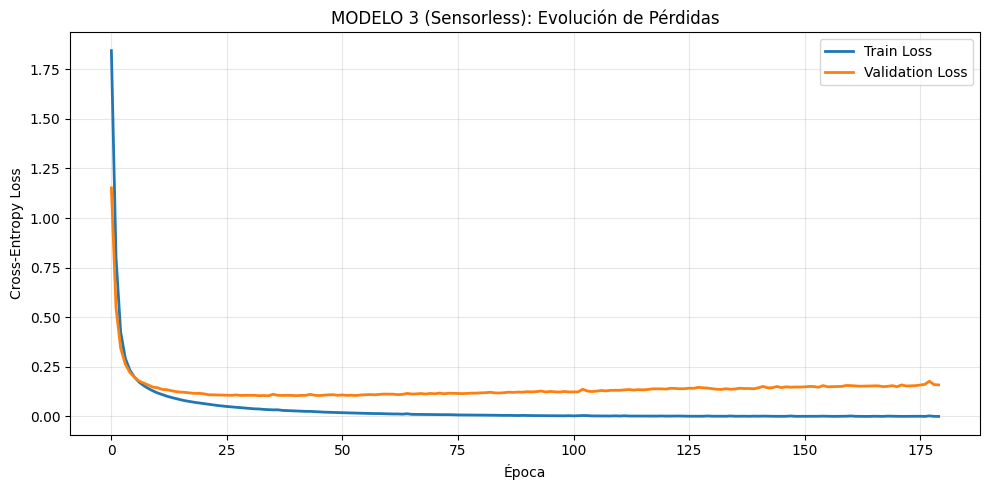

In [ ]:
# Graficar
plt.figure(figsize=(10, 5))
plt.plot(losses_sensor, label='Train Loss', linewidth=2)
plt.plot(val_losses_sensor, label='Validation Loss', linewidth=2)
plt.xlabel('Época')
plt.ylabel('Cross-Entropy Loss')
plt.title('MODELO 3 (Sensorless): Evolución de Pérdidas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

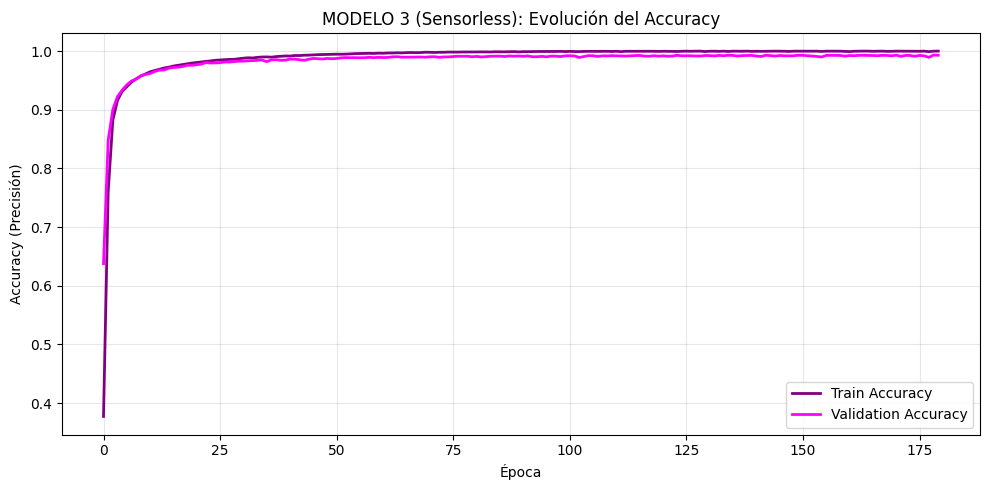

In [ ]:
# ==========================================
# NUEVO: GRAFICAR ACCURACY SENSORLESS
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(train_accs_sensor, label='Train Accuracy', linewidth=2, color='purple')
plt.plot(val_accs_sensor, label='Validation Accuracy', linewidth=2, color='magenta')
plt.xlabel('Época')
plt.ylabel('Accuracy (Precisión)')
plt.title('MODELO 3 (Sensorless): Evolución del Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.5 EVALUACIÓN Y MÉTRICAS

In [ ]:
# Predicciones
model_sensor.eval()
with torch.no_grad():
    y_logits_sensor = model_sensor(X_test_sensor_t)
    y_pred_sensor = torch.argmax(y_logits_sensor, dim=1).cpu().numpy()

# Accuracy global
accuracy_sensor = accuracy_score(y_test_sensor, y_pred_sensor)

print(f"\n{'='*50}")
print(f"EVALUACIÓN - MODELO 3 (SENSORLESS)")
print(f"{'='*50}")
print(f"Accuracy Global: {accuracy_sensor:.4f}")
print(f"\nAccuracy por clase:")

for clase in range(n_classes_sensorless):
    mask = y_test_sensor == clase
    if mask.sum() > 0:
        acc_clase = accuracy_score(y_test_sensor[mask], y_pred_sensor[mask])
        print(f"  Clase {clase} (Motor {'Intacto' if clase==0 else f'Fallo-{clase}'}): {acc_clase:.4f}")


EVALUACIÓN - MODELO 3 (SENSORLESS)
Accuracy Global: 0.9848

Accuracy por clase:
  Clase 0 (Motor Intacto): 0.9869
  Clase 1 (Motor Fallo-1): 0.9792
  Clase 2 (Motor Fallo-2): 0.9936
  Clase 3 (Motor Fallo-3): 0.9982
  Clase 4 (Motor Fallo-4): 0.9749
  Clase 5 (Motor Fallo-5): 0.9706
  Clase 6 (Motor Fallo-6): 1.0000
  Clase 7 (Motor Fallo-7): 0.9792
  Clase 8 (Motor Fallo-8): 0.9838
  Clase 9 (Motor Fallo-9): 0.9654
  Clase 10 (Motor Fallo-10): 1.0000


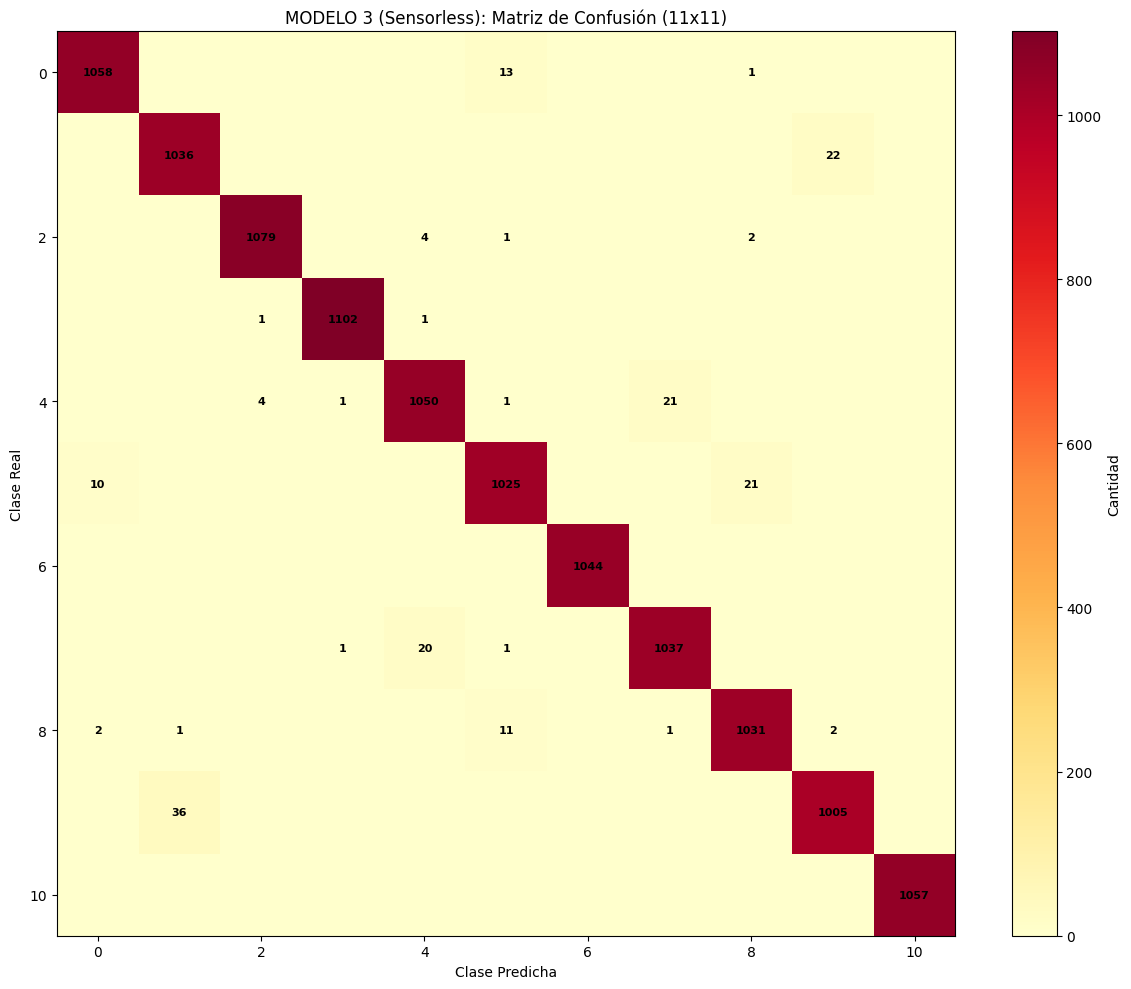

In [ ]:
# Matriz de confusión (comprimida para visualización)
cm_sensor = confusion_matrix(y_test_sensor, y_pred_sensor)
plt.figure(figsize=(12, 10))
plt.imshow(cm_sensor, cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Cantidad')

# Anotaciones en la matriz (USANDO SOLO MATPLOTLIB - solo valores significativos)
for i in range(len(cm_sensor)):
    for j in range(len(cm_sensor)):
        if cm_sensor[i, j] > 0:
            plt.text(j, i, str(cm_sensor[i, j]), ha='center', va='center',
                     color='black', fontsize=8, fontweight='bold')

plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.title('MODELO 3 (Sensorless): Matriz de Confusión (11x11)')
plt.tight_layout()
plt.show()

In [ ]:
# Guardar checkpoint
checkpoint_sensor = {
    'model_state_dict': model_sensor.state_dict(),
    'optimizer_state_dict': optimizer_sensor.state_dict(),
    'accuracy': accuracy_sensor,
    'num_classes': n_classes_sensorless,
    'normalization_params': {'mu': mu_sensor, 'sigma': sigma_sensor}
}

torch.save(checkpoint_sensor, 'model_sensorless_checkpoint.pth')
print(f"\n✓ Checkpoint guardado: 'model_sensorless_checkpoint.pth'")


✓ Checkpoint guardado: 'model_sensorless_checkpoint.pth'


---

## 📊 BLOQUE 4: COMPARATIVA DE RESULTADOS

Resumen de desempeño de los 3 modelos desarrollados.

In [ ]:
# Resumen de resultados
resumen = pd.DataFrame({
    'Modelo': ['Cars (Regresión)', 'DDoS (Binaria)', 'Sensorless (Multiclase)'],
    'Dataset': ['cars.csv', 'Friday-WorkingHours', 'Sensorless Drive'],
    'Ejemplos Train': [X_train_cars.shape[0], X_train_ddos.shape[0], X_train_sensor.shape[0]],
    'Características': [n_cars, n_ddos, n_sensor], # Corrected from n_sensorless to n_sensor
    'Métrica Principal': [f'R²={r2_cars:.4f}', f'Acc={accuracy_ddos:.4f}', f'Acc={accuracy_sensor:.4f}'],
    'Métrica Secundaria': [f'MAE=${mae_cars:.0f}', f'F1={f1_ddos:.4f}', 'Ver por Clase'],
    'Arquitectura': ['29-128-64-1', '78-256-128-64-1', '48-256-128-64-11'],
    'Épocas': [num_epochs_cars, num_epochs_ddos, num_epochs_sensor]
})

print(f"\n{'='*100}")
print(f"COMPARATIVA DE MODELOS")
print(f"{'='*100}")
print(resumen.to_string(index=False))
print(f"{'='*100}\n")


COMPARATIVA DE MODELOS
                 Modelo             Dataset  Ejemplos Train  Características Métrica Principal Métrica Secundaria     Arquitectura  Épocas
       Cars (Regresión)            cars.csv           30824               29         R²=0.7850          MAE=$1830      29-128-64-1     600
         DDoS (Binaria) Friday-WorkingHours          156348               78        Acc=0.9997          F1=0.9997  78-256-128-64-1      60
Sensorless (Multiclase)    Sensorless Drive           46807               48        Acc=0.9848      Ver por Clase 48-256-128-64-11     180



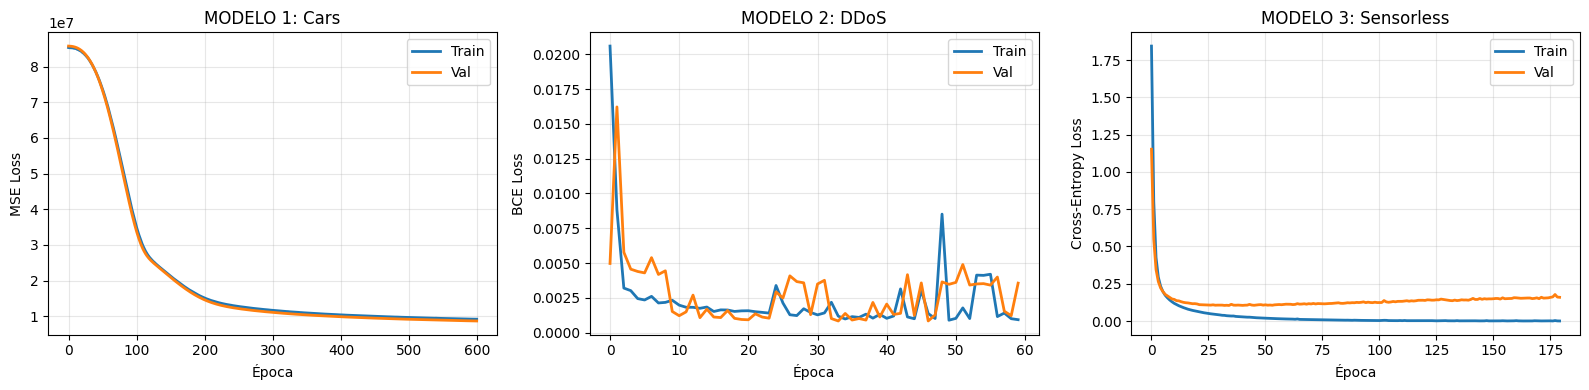

In [ ]:
# Visualizar pérdidas de los 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Cars
axes[0].plot(losses_cars, label='Train', linewidth=2)
axes[0].plot(val_losses_cars, label='Val', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('MODELO 1: Cars')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# DDoS
axes[1].plot(losses_ddos, label='Train', linewidth=2)
axes[1].plot(val_losses_ddos, label='Val', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('BCE Loss')
axes[1].set_title('MODELO 2: DDoS')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Sensorless
axes[2].plot(losses_sensor, label='Train', linewidth=2)
axes[2].plot(val_losses_sensor, label='Val', linewidth=2)
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Cross-Entropy Loss')
axes[2].set_title('MODELO 3: Sensorless')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 🚀 BLOQUE 5: DEPLOYMENT Y REPRODUCCIÓN

### 5.1 Funciones para Cargar y Usar Modelos en el Futuro

In [ ]:
def cargar_modelo_cars(checkpoint_path, device):
    """Carga el modelo de precios de vehículos"""
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    modelo = RegressionNN_Cars(input_size=29).to(device)
    modelo.load_state_dict(checkpoint['model_state_dict'])
    modelo.eval()
    norm_params = checkpoint['normalization_params']
    return modelo, norm_params

def predecir_precio(X_raw, modelo, norm_params, device):
    """Predice precios dado características raw"""
    X_norm = (X_raw - norm_params['mu']) / norm_params['sigma']
    X_t = torch.from_numpy(X_norm).float().to(device)
    with torch.no_grad():
        y_pred = modelo(X_t).cpu().numpy()
    return y_pred

print(f"✓ Función de predicción para Cars definida")

✓ Función de predicción para Cars definida


In [ ]:
def cargar_modelo_ddos(checkpoint_path, device):
    """Carga el modelo de detección DDoS"""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    modelo = BinaryClassifierNN_DDoS(input_size=78).to(device)
    modelo.load_state_dict(checkpoint['model_state_dict'])
    modelo.eval()
    norm_params = checkpoint['normalization_params']
    return modelo, norm_params

def predecir_ddos(X_raw, modelo, norm_params, device, threshold=0.5):
    """Predice si es ataque DDoS"""
    X_norm = (X_raw - norm_params['mu']) / norm_params['sigma']
    X_t = torch.from_numpy(X_norm).float().to(device)
    with torch.no_grad():
        prob = modelo(X_t).cpu().numpy()
    pred = (prob >= threshold).astype(int)
    return prob, pred

print(f"✓ Función de predicción para DDoS definida")

✓ Función de predicción para DDoS definida


In [ ]:
def cargar_modelo_sensorless(checkpoint_path, device):
    """Carga el modelo de diagnóstico de motores"""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    n_classes = checkpoint['num_classes']
    modelo = MulticlassNN_Sensorless(input_size=48, num_classes=n_classes).to(device)
    modelo.load_state_dict(checkpoint['model_state_dict'])
    modelo.eval()
    norm_params = checkpoint['normalization_params']
    return modelo, norm_params, n_classes

def predecir_estado_motor(X_raw, modelo, norm_params, device):
    """Predice estado del motor (0-10)"""
    X_norm = (X_raw - norm_params['mu']) / norm_params['sigma']
    X_t = torch.from_numpy(X_norm).float().to(device)
    with torch.no_grad():
        logits = modelo(X_t)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred = torch.argmax(logits, dim=1).cpu().numpy()
    return pred, probs

print(f"✓ Función de predicción para Sensorless definida")

✓ Función de predicción para Sensorless definida


### 5.2 Ejemplo de Uso: Predicción con Modelos Cargados

In [ ]:
# ============================================================
# EJEMPLO: Predicción con Modelo Cars Guardado
# ============================================================

# Cargar el modelo desde el disco simulando un entorno de producción
modelo_cars_demo, norm_params_cars = cargar_modelo_cars('model_cars_best.pth', device)

# Extraer 3 ejemplos aleatorios del Test Set (datos no vistos)
# Fijamos la semilla para que en la defensa los resultados sean estables
np.random.seed(15)
indices_sample_for_demo = np.random.choice(len(X_test_cars), size=3, replace=False)
X_demo = X_test_cars[indices_sample_for_demo]
y_real = y_test_cars[indices_sample_for_demo]

# Realizar la inferencia con la función de producción
y_demo = predecir_precio(X_demo, modelo_cars_demo, norm_params_cars, device)

print(f"\n{'='*60}")
print(f"EJEMPLO DE INFERENCIA EN PRODUCCIÓN (MODELO CARS)")
print(f"{'='*60}")

for i in range(len(X_demo)):
    print(f"\n🚘 Vehículo de prueba {i+1}:")
    print(f"  ▶ Precio REAL en mercado: ${y_real[i]:,.0f}")
    print(f"  ▶ Precio PREDICHO:        ${y_demo[i][0]:,.0f}")

    # Calculamos la diferencia absoluta en dinero, no en porcentaje
    error_abs = abs(y_real[i] - y_demo[i][0])
    print(f"  ▶ Diferencia de tasación: ${error_abs:,.0f}")


EJEMPLO DE INFERENCIA EN PRODUCCIÓN (MODELO CARS)

🚘 Vehículo de prueba 1:
  ▶ Precio REAL en mercado: $7,100
  ▶ Precio PREDICHO:        $7,569
  ▶ Diferencia de tasación: $469

🚘 Vehículo de prueba 2:
  ▶ Precio REAL en mercado: $9,000
  ▶ Precio PREDICHO:        $12,239
  ▶ Diferencia de tasación: $3,239

🚘 Vehículo de prueba 3:
  ▶ Precio REAL en mercado: $2,850
  ▶ Precio PREDICHO:        $4,124
  ▶ Diferencia de tasación: $1,274
